# Danny's Pizza — Dataset Scaffold (OscarF Datasets generator)

> Add blockquote



**Created:** 2025-08-22 00:39

This notebook sets up the **small tables** in-notebook and expects the **large order tables** to be loaded from CSV/XLS files.
It strictly follows the schema from class:

- `pizza_names(pizza_id INT, pizza_name TEXT)`
- `pizza_toppings(topping_id INT, topping_name TEXT)`
- `pizza_recipes(pizza_id INT, toppings TEXT)` where `toppings` is a comma-separated list of `topping_id`s
- `runners(runner_id INT, registration_date DATE)`
- `customer_orders(order_id INT, customer_id INT, pizza_id INT, exclusions VARCHAR(4), extras VARCHAR(4), order_date TIMESTAMP)`
- `runner_orders(order_id INT, runner_id INT, pickup_time VARCHAR(19), distance VARCHAR(7), duration VARCHAR(10), cancellation VARCHAR(23))`



In [1]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#base_path = '/content/drive/MyDrive/BLOQUE I.A./Notebooks/'
%ls

 El volumen de la unidad C es OS
 El n£mero de serie del volumen es: 28A3-2B7F

 Directorio de C:\Users\luisn\OneDrive\Documents\GitHub\IAA\BigData_Hadoop - Oscar\Dannys_pizza

12/09/2025  05:48 p. m.    <DIR>          .
05/09/2025  06:32 p. m.    <DIR>          ..
12/09/2025  05:48 p. m.    <DIR>          .ipynb_checkpoints
12/09/2025  05:48 p. m.             2,396 cluster.png
22/08/2025  06:59 p. m.            71,422 customer_orders.csv
22/08/2025  06:59 p. m.    <DIR>          dannys_data
12/09/2025  05:48 p. m.           180,224 dannys_pizza.sqlite
12/09/2025  05:48 p. m.         1,332,144 Dannys_Pizza_week2_HWK.ipynb
11/09/2025  06:57 p. m.               120 pizza_names.csv
11/09/2025  06:57 p. m.               121 pizza_recipes.csv
11/09/2025  06:57 p. m.               211 pizza_toppings.csv
22/08/2025  06:59 p. m.            65,407 runner_orders.csv
11/09/2025  06:57 p. m.               245 runners.csv
29/08/2025  05:02 p. m.           204,594 Solved_Dannys_Pizza-2.ipynb
       

In [2]:
import pandas as pd

## Create Small Tables (Dims)

We define a **minimal, realistic** pizza catalog.


In [3]:
# --- pizza_names ---
pizza_names = pd.DataFrame({
    'pizza_id': [1, 2, 3, 4, 5, 6, 7],
    'pizza_name': [
        'Margherita',        # 1
        'Vegetarian',        # 2
        'Meat Lovers',       # 3
        'BBQ Chicken',       # 4
        'Hawaiian',          # 5
        'Pepperoni',         # 6
        'Vegan Veggie'       # 7  <-- vegan option (no cheese by default)
    ]
})
pizza_names.to_csv('pizza_names.csv', index=False)
pizza_names

,pizza_id,pizza_name
0,1,Margherita
1,2,Vegetarian
2,3,Meat Lovers
3,4,BBQ Chicken
4,5,Hawaiian
5,6,Pepperoni
6,7,Vegan Veggie


In [4]:
# --- pizza_toppings ---
# Concise list so students can reason about extras/exclusions clearly
pizza_toppings = pd.DataFrame({
    'topping_id': list(range(1, 16)),
    'topping_name': [
        'Tomato Sauce',  # 1
        'Mozzarella',    # 2
        'Mushroom',      # 3
        'Onion',         # 4
        'Bell Pepper',   # 5
        'Olives',        # 6
        'Pepperoni',     # 7
        'Bacon',         # 8
        'Beef',          # 9
        'Chicken',       # 10
        'Pineapple',     # 11
        'BBQ Sauce',     # 12
        'Jalapeno',      # 13
        'Fresh Basil',   # 14
        'Garlic'         # 15
    ]
})
pizza_toppings.to_csv('pizza_toppings.csv', index=False)
pizza_toppings

,topping_id,topping_name
0,1,Tomato Sauce
1,2,Mozzarella
2,3,Mushroom
3,4,Onion
4,5,Bell Pepper
5,6,Olives
6,7,Pepperoni
7,8,Bacon
8,9,Beef
9,10,Chicken


In [5]:
# --- pizza_recipes ---
# Define base recipes as comma-separated topping_id strings (order does not matter)
recipes_map = {
    1: [1,2,14],               # Margherita: sauce, mozzarella, basil
    2: [1,2,3,4,5,6],          # Vegetarian: sauce, mozzarella, mushroom, onion, bell pepper, olives
    3: [1,2,7,8,9],            # Meat Lovers: sauce, mozzarella, pepperoni, bacon, beef
    4: [1,2,10,12],            # BBQ Chicken: sauce, mozzarella, chicken, bbq sauce
    5: [1,2,11,6],             # Hawaiian: sauce, mozzarella, pineapple, olives
    6: [1,2,7],                # Pepperoni: sauce, mozzarella, pepperoni
    7: [1,3,4,5,6,15]          # Vegan Veggie: sauce, mushroom, onion, bell pepper, olives, garlic (no cheese)
}

pizza_recipes = pd.DataFrame({
    'pizza_id': list(recipes_map.keys()),
    'toppings': [','.join(map(str, v)) for v in recipes_map.values()]
})
pizza_recipes.to_csv('pizza_recipes.csv', index=False)
pizza_recipes

,pizza_id,toppings
0,1,"1,2,14"
1,2,"1,2,3,4,5,6"
2,3,"1,2,7,8,9"
3,4,"1,2,10,12"
4,5,"1,2,11,6"
5,6,"1,2,7"
6,7,"1,3,4,5,6,15"


In [6]:
# --- runners ---

dates = pd.date_range('2021-01-03', periods=15, freq='7D')
runners = pd.DataFrame({
    'runner_id': range(1, 16),
    'registration_date': dates.date
})
runners.to_csv('runners.csv', index=False)
runners

,runner_id,registration_date
0,1,2021-01-03
1,2,2021-01-10
2,3,2021-01-17
3,4,2021-01-24
4,5,2021-01-31
5,6,2021-02-07
6,7,2021-02-14
7,8,2021-02-21
8,9,2021-02-28
9,10,2021-03-07


## Load Orders

This cell loads the orders from CSV first; if not present, it tries XLSX. Adjust file paths if needed.


## Cleaning & Normalization Helpers

- Parse `distance` (to float km) and `duration` (to minutes).
- Normalize `cancellation` labels (lowercase, strip).
- Enforce FK integrity and logical constraints.


In [7]:

import numpy as np

# Base path in Google Drive


# --- Load small dimension tables ---
pizza_names     = pd.read_csv('pizza_names.csv')
pizza_toppings  = pd.read_csv('pizza_toppings.csv')
pizza_recipes   = pd.read_csv('pizza_recipes.csv')
runners         = pd.read_csv('runners.csv')

# --- Load big fact tables ---
customer_orders = pd.read_csv('customer_orders.csv')
runner_orders   = pd.read_csv('runner_orders.csv')

print("pizza_names:", pizza_names.shape)
print("pizza_toppings:", pizza_toppings.shape)
print("pizza_recipes:", pizza_recipes.shape)
print("runners:", runners.shape)
print("customer_orders:", customer_orders.shape)
print("runner_orders:", runner_orders.shape)


pizza_names: (7, 2)
pizza_toppings: (15, 2)
pizza_recipes: (7, 2)
runners: (15, 2)
customer_orders: (2101, 6)
runner_orders: (1500, 6)


In [8]:
customer_orders.head()

,order_id,customer_id,pizza_id,exclusions,extras,order_date
0,2481,500,2,NaN,NaN,2025-02-21 16:06:46
1,1897,269,6,NaN,NaN,2025-08-12 08:27:50
2,1842,59,7,NaN,NaN,2024-12-23 20:50:23
3,1869,710,6,NaN,NaN,2025-01-31 09:16:49
4,2384,189,3,NaN,NaN,2024-11-30 17:35:37




```
# This is formatted as code
```


# /* --------------------
#   Case Study Questions
#   --------------------*/
A. Pizza Metrics

    How many pizzas were ordered?
    How many unique customer orders were made?
    How many successful orders were delivered by each runner?
    How many of each type of pizza was delivered?
    How many Vegetarian and Meatlovers were ordered by each customer?
    What was the maximum number of pizzas delivered in a single order?
    For each customer, how many delivered pizzas had at least 1 change and how many had no changes?
    How many pizzas were delivered that had both exclusions and extras?
    What was the total volume of pizzas ordered for each hour of the day?
    What was the volume of orders for each day of the week?

B. Runner and Customer Experience

    How many runners signed up for each 1 week period? (i.e. week starts 2021-01-01)
    What was the average time in minutes it took for each runner to arrive at the Pizza Runner HQ to pickup the order?
    Is there any relationship between the number of pizzas and how long the order takes to prepare?
    What was the average distance travelled for each customer?
    What was the difference between the longest and shortest delivery times for all orders?
    What was the average speed for each runner for each delivery and do you notice any trend for these values?
    What is the successful delivery percentage for each runner?

🍕 section c — customer & business intelligence

C1. total customer spend
 which customers bring in the most revenue?

use to argue for vip memberships or spend-based rewards.

C2. customer frequency (distinct days of orders)
 who orders regularly vs. one-off customers?

segment into loyal customers vs. occasional customers.

hint at frequency-based discounts (e.g., 5th order free).

C3. first pizza ordered by each customer
 what attracts customers initially?

good to identify entry-point pizzas (the hook item that brings people in).

hint at discounts on first-order pizzas to acquire new customers.

C4. overall best-seller pizza
 which pizza keeps the lights on?

highlight as a flagship product to promote.

use for seasonal bundles (“summer deal with our #1 pizza”).

C5. most popular pizza by customer
 can we personalize offers?

recommend personalized “customer favorites” discounts.

hint toward AI/BI-driven recommender systems.

C6. regulars with ≥30 orders and their go-to pizzas
 who are the heavy hitters and what do they like?

obvious loyalty program candidates.

pitch: “keep them happy with exclusive rewards so they don’t churn.”

C7. customers with very consistent habits (always order the same pizza)
 creatures of habit = stable recurring revenue.

membership idea: “pizza subscription” (weekly plan with their pizza auto-delivered).

C8. the “perfect pair”

great marketing story: “find your pizza soulmate.”

pitch: social media campaign + 2-for-1  perfect pizza couples’ promo.

C9. peak order times
👉 what hours & days matter most?

operational: staff scheduling.

marketing: happy hour discounts in slow periods, premium pricing at peak times.

C10. best candidates for loyalty program
👉 combine spend + frequency + consistency.

identify top 5–10% customers.

suggest tiered memberships: silver/gold/platinum.

seasonal perks: double points in winter when sales slow.

# Entregable

final presentation = a business intelligence pitch deck:

customer segmentation (loyal vs occasional vs perfect pair).

menu insights (flagship pizza, first-order hook, personal favorites).

time insights (peak hours, seasonal discounts).

strategic recommendations:

loyalty program design,

subscription/membership tiers,

seasonal & time-based promos,

“perfect pair” marketing campaign.

In [9]:
import sqlite3

db_path = f"dannys_pizza.sqlite"
conn = sqlite3.connect(db_path)
c = conn.cursor()

# drop existing tables (clean slate)
for t in [
    'pizza_names','pizza_toppings','pizza_recipes',
    'runners','customer_orders','runner_orders'
]:
    c.execute(f"DROP TABLE IF EXISTS {t};")

# create empty tables with the canonical column names
c.execute("""CREATE TABLE pizza_names (
  pizza_id INTEGER,
  pizza_name TEXT
);""")

c.execute("""CREATE TABLE pizza_toppings (
  topping_id INTEGER,
  topping_name TEXT
);""")

c.execute("""CREATE TABLE pizza_recipes (
  pizza_id INTEGER,
  toppings TEXT
);""")

c.execute("""CREATE TABLE runners (
  runner_id INTEGER,
  registration_date TEXT
);""")

# NOTE: keep your current column names exactly as they are in the DataFrame
# If your DF uses 'order_date', keep it; if it's 'order_time', keep that.
# Below uses 'order_date'—change to 'order_time' if that’s your DF.
c.execute("""CREATE TABLE customer_orders (
  order_id INTEGER,
  customer_id INTEGER,
  pizza_id INTEGER,
  exclusions TEXT,
  extras TEXT,
  order_date TEXT
);""")

c.execute("""CREATE TABLE runner_orders (
  order_id INTEGER,
  runner_id INTEGER,
  pickup_time TEXT,
  distance TEXT,
  duration TEXT,
  cancellation TEXT
);""")

conn.commit()

# append DataFrames exactly as-is (no cleaning)
pizza_names.to_sql('pizza_names', conn, if_exists='append', index=False)
pizza_toppings.to_sql('pizza_toppings', conn, if_exists='append', index=False)
pizza_recipes.to_sql('pizza_recipes', conn, if_exists='append', index=False)
runners.to_sql('runners', conn, if_exists='append', index=False)
customer_orders.to_sql('customer_orders', conn, if_exists='append', index=False)
runner_orders.to_sql('runner_orders', conn, if_exists='append', index=False)

conn.commit()
print("SQLite ready at:", db_path)


SQLite ready at: dannys_pizza.sqlite


* Q1. How many pizzas were ordered?

In [10]:
pd.read_sql("""
SELECT COUNT(*) AS total_pizzas
FROM customer_orders;
""", conn)


,total_pizzas
0,2101


In [11]:
pd.read_sql("""
SELECT COUNT(DISTINCT order_id) AS unique_orders
FROM customer_orders;
""", conn)


,unique_orders
0,1500


In [12]:
##pd.read_sql("YOUR QUERY HERE", conn)  # TODO


In [13]:
pd.read_sql("""
SELECT runner_id,
       COUNT(runner_id) AS order_count
FROM runner_orders
WHERE distance IS NOT NULL
  AND TRIM(distance) <> ''
  AND cancellation = ''
GROUP BY runner_id
ORDER BY order_count DESC;
""", conn)


,runner_id,order_count


Notice how our query returned empty results? That is a clue something is off in our filter. We wrote
WHERE distance IS NOT NULL
  AND cancellation = ''''

  but in this dataset, the cancellation column does not only use a blank string to mean no cancellation. Sometimes it has the literal word 'null', sometimes it is NULL (the SQL null value), sometimes different casing (Null, NULL). Because of that, our =  condition excluded almost everything.

In [14]:
  pd.read_sql("""
SELECT DISTINCT TRIM(cancellation) AS cancellation_value,
       COUNT(*) AS n
FROM runner_orders
GROUP BY 1
ORDER BY n DESC;
""", conn)


,cancellation_value,n
0,None,1450
1,address issue,13
2,customer no show,9
3,runner sick,7
4,order late,7
5,custmer_no_sho,7
6,runner_unavailable,5
7,restaurant_cancelled,2


In [15]:
# 3a) Successful orders delivered by each runner (ignore distance presence)
pd.read_sql("""
SELECT runner_id,
       COUNT(*) AS order_count
FROM runner_orders
WHERE COALESCE(TRIM(LOWER(cancellation)),'') IN ('', 'null')
GROUP BY runner_id
ORDER BY order_count DESC;
""", conn)


,runner_id,order_count
0,3,115
1,14,112
2,2,110
3,5,109
4,7,101
5,12,96
6,11,96
7,1,93
8,8,92
9,13,91


In [16]:
#How many unique customer orders were made? YAAA 
#How many successful orders were delivered by each runner? YAAA 
#How many of each type of pizza was delivered? YAAA
#How many Vegetarian and Meatlovers were ordered by each customer?
#What was the maximum number of pizzas delivered in a single order?
#For each customer, how many delivered pizzas had at least 1 change and how many had no changes?
#How many pizzas were delivered that had both exclusions and extras?
#What was the total volume of pizzas ordered for each hour of the day?
#What was the volume of orders for each day of the week?

In [18]:
#How many of each type of pizza was delivered?
pd.read_sql("""
SELECT co.pizza_id,pn.pizza_name,COUNT(order_id) 
FROM customer_orders co
JOIN pizza_names as pn
ON co.pizza_id = pn.pizza_id
GROUP BY co.pizza_id
""", conn)


,pizza_id,pizza_name,COUNT(order_id)
0,1,Margherita,235
1,2,Vegetarian,340
2,3,Meat Lovers,468
3,4,BBQ Chicken,278
4,5,Hawaiian,218
5,6,Pepperoni,398
6,7,Vegan Veggie,164


In [19]:
#How many Vegetarian and Meatlovers were ordered by each customer?
pd.read_sql("""
SELECT co.customer_id,COUNT(order_id) as ordenes 
FROM customer_orders co
JOIN pizza_names as pn
ON co.pizza_id = pn.pizza_id
WHERE co.pizza_id IN (2,3)
GROUP BY co.pizza_id, co.customer_id
""", conn)

,customer_id,ordenes
0,5,4
1,11,1
2,15,1
3,16,1
4,17,1
...,...,...
433,778,1
434,781,1
435,785,1
436,790,1


In [20]:
#What was the maximum number of pizzas delivered in a single order?
pd.read_sql("""
SELECT order_id, COUNT(pizza_id)
FROM customer_orders
GROUP BY order_id
ORDER BY COUNT(pizza_id) DESC
""", conn)

,order_id,COUNT(pizza_id)
0,2441,4
1,2417,4
2,1994,4
3,1930,4
4,1805,4
...,...,...
1495,1007,1
1496,1005,1
1497,1003,1
1498,1002,1


In [21]:
#How many pizzas were delivered that had both exclusions and extras?
pd.read_sql("""
SELECT COUNT(*)
FROM customer_orders
WHERE extras IS NOT NULL and exclusions IS NOT NULL""", conn)

,COUNT(*)
0,198


In [22]:
#What was the total volume of pizzas ordered for each hour of the day?
pd.read_sql("""
SELECT COUNT(order_id),strftime('%H', order_date) as hora
FROM customer_orders
GROUP BY strftime('%H', order_date)""", conn)


,COUNT(order_id),hora
0,66,00
1,39,01
2,49,02
3,59,03
4,54,04
5,28,05
6,74,06
7,36,07
8,43,08
9,67,09


In [23]:
#What was the volume of orders for each day of the week?
pd.read_sql("""
SELECT 
    CASE CAST( strftime('%w', order_date) as INTEGER)
    WHEN 0 THEN 'Sunday'
    WHEN 1 THEN 'Monday'
    WHEN 2 THEN 'Tuesday'
    WHEN 3 THEN 'Wednesday'
    WHEN 4 THEN 'Thursday'
    WHEN 5 THEN 'Friday'
    ELSE 'Saturday'
    END AS dia,
    COUNT(order_id)
FROM customer_orders
GROUP BY strftime('%w', order_date)""", conn)

,dia,COUNT(order_id)
0,Sunday,439
1,Monday,176
2,Tuesday,177
3,Wednesday,190
4,Thursday,251
5,Friday,417
6,Saturday,451


In [24]:
#

In [25]:
pd.read_sql("""
SELECT co.customer_id,COUNT(order_id) as ordenes 
FROM customer_orders co
GROUP BY co.customer_id
ORDER BY ordenes DESC
LIMIT 18""", conn)

,customer_id,ordenes
0,620,58
1,500,54
2,730,53
3,657,52
4,30,52
5,717,51
6,547,49
7,180,49
8,240,47
9,45,45


In [26]:
#What was the month 
pd.read_sql("""
SELECT 
    CASE CAST( strftime('%m', order_date) as INTEGER)
    WHEN 1 THEN 'Enero'
    WHEN 2 THEN 'Febrero'
    WHEN 3 THEN 'Marzo'
    WHEN 4 THEN 'Abril'
    WHEN 5 THEN 'Mayo'
    WHEN 6 THEN 'Junio'
    WHEN 7 THEN 'Julio'
    WHEN 8 THEN 'Agosto'
    WHEN 9 THEN 'Septiembre'
    WHEN 10 THEN 'Octubre'
    WHEN 11 THEN 'Noviembre'
    WHEN 12 THEN 'Diciembre'
    ELSE 'Mes inválido'
    END AS dia,
    COUNT(order_id)
FROM customer_orders
GROUP BY strftime('%m', order_date)""", conn)

,dia,COUNT(order_id)
0,Enero,238
1,Febrero,244
2,Marzo,202
3,Abril,184
4,Mayo,254
5,Junio,230
6,Julio,208
7,Agosto,108
8,Noviembre,226
9,Diciembre,207


In [17]:
#What was the month 
new_df = pd.read_sql("""
SELECT customer_id, pizza_id,sum(pizza_id) as cantidad, order_date
FROM customer_orders
GROUP BY customer_id, pizza_id
""", conn)

In [18]:
new_df

,customer_id,pizza_id,cantidad,order_date
0,1,3,3,2025-02-16 16:20:47
1,1,4,4,2025-02-16 16:20:47
2,1,6,6,2025-05-12 22:40:43
3,2,1,1,2025-06-15 12:46:53
4,2,3,3,2025-06-15 12:46:53
...,...,...,...,...
1218,794,6,12,2025-02-04 18:50:06
1219,796,1,1,2025-08-09 19:45:06
1220,796,2,4,2025-01-07 09:43:20
1221,796,6,6,2024-11-27 16:23:45


In [19]:
pivot_df = pd.pivot_table(new_df, values='cantidad', index=['customer_id'], columns=['pizza_id'], aggfunc="sum")

In [20]:
pivot_df.head(14)

pizza_id,1,2,3,4,5,6,7
customer_id,,,,,,,
1,NaN,NaN,3.0,4.0,NaN,6.0,NaN
2,1.0,NaN,3.0,NaN,NaN,NaN,NaN
3,NaN,NaN,3.0,NaN,NaN,6.0,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2.0,8.0,21.0,28.0,15.0,36.0,21.0
7,NaN,NaN,NaN,4.0,NaN,NaN,NaN
8,1.0,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,6.0,7.0
10,NaN,NaN,3.0,NaN,NaN,NaN,NaN


In [21]:
pivot_df = pivot_df.fillna(0)

In [22]:
pivot_df.head(14)

pizza_id,1,2,3,4,5,6,7
customer_id,,,,,,,
1,0.0,0.0,3.0,4.0,0.0,6.0,0.0
2,1.0,0.0,3.0,0.0,0.0,0.0,0.0
3,0.0,0.0,3.0,0.0,0.0,6.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,8.0,21.0,28.0,15.0,36.0,21.0
7,0.0,0.0,0.0,4.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,6.0,7.0
10,0.0,0.0,3.0,0.0,0.0,0.0,0.0


In [23]:
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(pivot_df)
import pandas as pd
sim_df = pd.DataFrame(sim_matrix, index=pivot_df.index, columns=pivot_df.index)
print(sim_df.head())


customer_id       1         2         3         4         5         7    \
customer_id                                                               
1            1.000000  0.364399  0.858898  0.000000  0.877478  0.512148   
2            0.364399  1.000000  0.424264  0.316228  0.360278  0.000000   
3            0.858898  0.424264  1.000000  0.000000  0.728991  0.000000   
4            0.000000  0.316228  0.000000  1.000000  0.035055  0.000000   
5            0.877478  0.360278  0.728991  0.035055  1.000000  0.490775   

customer_id       8         9         10        11   ...       782       783  \
customer_id                                          ...                       
1            0.000000  0.499952  0.384111  0.000000  ...  0.765568  0.000000   
2            0.316228  0.000000  0.948683  0.000000  ...  0.026261  0.000000   
3            0.000000  0.582086  0.447214  0.000000  ...  0.891338  0.000000   
4            1.000000  0.000000  0.000000  0.000000  ...  0.083045  0.0000

In [24]:
# Para cada cliente, encontrar el gemelo más parecido
gemelos = {}

for customer in sim_df.index:
    # Excluirse a sí mismo
    similitudes = sim_df.loc[customer].drop(customer)
    gemelo = similitudes.idxmax()
    score = similitudes.max()
    gemelos[customer] = (gemelo, score)

# Ver resultados
for cliente, (gemelo, score) in gemelos.items():
    if score==1.0:
        print(f"Cliente {cliente} es más parecido a Cliente {gemelo} (similitud={score:.2f})")

Cliente 1 es más parecido a Cliente 14 (similitud=1.00)
Cliente 2 es más parecido a Cliente 122 (similitud=1.00)
Cliente 4 es más parecido a Cliente 8 (similitud=1.00)
Cliente 7 es más parecido a Cliente 60 (similitud=1.00)
Cliente 8 es más parecido a Cliente 4 (similitud=1.00)
Cliente 9 es más parecido a Cliente 28 (similitud=1.00)
Cliente 10 es más parecido a Cliente 24 (similitud=1.00)
Cliente 11 es más parecido a Cliente 64 (similitud=1.00)
Cliente 12 es más parecido a Cliente 383 (similitud=1.00)
Cliente 14 es más parecido a Cliente 1 (similitud=1.00)
Cliente 15 es más parecido a Cliente 266 (similitud=1.00)
Cliente 16 es más parecido a Cliente 459 (similitud=1.00)
Cliente 22 es más parecido a Cliente 33 (similitud=1.00)
Cliente 24 es más parecido a Cliente 10 (similitud=1.00)
Cliente 27 es más parecido a Cliente 10 (similitud=1.00)
Cliente 28 es más parecido a Cliente 9 (similitud=1.00)
Cliente 33 es más parecido a Cliente 22 (similitud=1.00)
Cliente 35 es más parecido a Cliente 

In [25]:
#What was the month 
new_df2 = pd.read_sql("""
SELECT customer_id, order_id, pizza_id,sum(pizza_id) as cantidad
FROM customer_orders
GROUP BY customer_id, pizza_id
""", conn)

In [26]:
new_df2

,customer_id,order_id,pizza_id,cantidad
0,1,2460,3,3
1,1,2460,4,4
2,1,1990,6,6
3,2,2444,1,1
4,2,2444,3,3
...,...,...,...,...
1218,794,1840,6,12
1219,796,1480,1,1
1220,796,2491,2,4
1221,796,1837,6,6


In [27]:
pivot_df2 = pd.pivot_table(new_df2, values='cantidad', index=['customer_id','order_id'], columns=['pizza_id'], aggfunc="sum")

In [28]:
pivot_df2.head()

pizza_id                1   2    3    4   5    6   7
customer_id order_id                                
1           1990      NaN NaN  NaN  NaN NaN  6.0 NaN
            2460      NaN NaN  3.0  4.0 NaN  NaN NaN
2           2444      1.0 NaN  3.0  NaN NaN  NaN NaN
3           1197      NaN NaN  3.0  NaN NaN  NaN NaN
            1989      NaN NaN  NaN  NaN NaN  6.0 NaN

In [29]:
pivot_df2 = pivot_df2.fillna(0)

In [30]:
pivot_df2.head()

pizza_id                1    2    3    4    5    6    7
customer_id order_id                                   
1           1990      0.0  0.0  0.0  0.0  0.0  6.0  0.0
            2460      0.0  0.0  3.0  4.0  0.0  0.0  0.0
2           2444      1.0  0.0  3.0  0.0  0.0  0.0  0.0
3           1197      0.0  0.0  3.0  0.0  0.0  0.0  0.0
            1989      0.0  0.0  0.0  0.0  0.0  6.0  0.0

In [31]:
corr_pedidos = pivot_df2.T.corr(method='pearson')
print(corr_pedidos)

customer_id                1                   2         3              \
order_id                  1990      2460      2444      1197      1989   
customer_id order_id                                                     
1           1990      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
            2460     -0.254588  1.000000  0.424313  0.509175 -0.254588   
2           2444     -0.222222  0.424313  1.000000  0.944444 -0.222222   
3           1197     -0.166667  0.509175  0.944444  1.000000 -0.166667   
            1989      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
...                        ...       ...       ...       ...       ...   
794         1840      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
796         1480     -0.166667 -0.254588  0.166667 -0.166667 -0.166667   
            1837      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
            2491     -0.166667 -0.254588 -0.222222 -0.166667 -0.166667   
798         1286     -0.166667 -0.2545

In [32]:
corr_pedidos.head()

customer_id                1                   2         3              \
order_id                  1990      2460      2444      1197      1989   
customer_id order_id                                                     
1           1990      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
            2460     -0.254588  1.000000  0.424313  0.509175 -0.254588   
2           2444     -0.222222  0.424313  1.000000  0.944444 -0.222222   
3           1197     -0.166667  0.509175  0.944444  1.000000 -0.166667   
            1989      1.000000 -0.254588 -0.222222 -0.166667  1.000000   

customer_id                4         5                                  ...  \
order_id                  1294      1131      1289      1398      1804  ...   
customer_id order_id                                                    ...   
1           1990     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
            2460     -0.254588 -0.254588 -0.254588  0.752651 -0.254588  ...   
2           2444      0.166667 -0.222222 -0.222222 -0.212313 -0.222222  ...   
3           1197     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
            1989     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   

customer_id                790                           791       793  \
order_id                  1399      1772      2087      1612      1064   
customer_id order_id                                                     
1           1990     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   
            2460     -0.254588  0.509175 -0.254588 -0.254588  0.509175   
2           2444      0.166667  0.944444 -0.222222 -0.222222  0.944444   
3           1197     -0.166667  1.000000 -0.166667 -0.166667  1.000000   
            1989     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   

customer_id                794       796                           798  
order_id                  1840      1480      1837      2491      1286  
customer_id order_id                                                    
1           1990      1.000000 -0.166667  1.000000 -0.166667 -0.166667  
            2460     -0.254588 -0.254588 -0.254588 -0.254588 -0.254588  
2           2444     -0.222222  0.166667 -0.222222 -0.222222 -0.222222  
3           1197     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667  
            1989      1.000000 -0.166667  1.000000 -0.166667 -0.166667  

[5 rows x 995 columns]

In [33]:
# Información básica de la matriz
print(f"Forma de la matriz: {corr_pedidos.shape}")
print(f"Rango de correlaciones: {corr_pedidos.min().min():.3f} a {corr_pedidos.max().max():.3f}")

# Estadísticas descriptivas (excluyendo la diagonal)
import numpy as np
mask = np.eye(corr_pedidos.shape[0], dtype=bool)
corr_sin_diagonal = corr_pedidos.values[~mask]
print(f"Media de correlaciones: {np.mean(corr_sin_diagonal):.3f}")
print(f"Desviación estándar: {np.std(corr_sin_diagonal):.3f}")

Forma de la matriz: (995, 995)
Rango de correlaciones: -0.602 a 1.000
Media de correlaciones: 0.014
Desviación estándar: 0.418


# Método alternativo más claro
import numpy as np

# Obtener solo la triangular inferior (sin diagonal)
indices = np.tril_indices_from(corr_pedidos, k=-1)
valores_correlacion = corr_pedidos.values[indices]
indices_nombres = [(corr_pedidos.index[i], corr_pedidos.columns[j]) 
                   for i, j in zip(indices[0], indices[1])]

# Crear Serie con los pares de nombres como índice
correlaciones_serie = pd.Series(valores_correlacion, 
                                index=pd.MultiIndex.from_tuples(indices_nombres))

# Top correlaciones
print("Top 10 correlaciones positivas:")
print(correlaciones_serie.nlargest(10))

print("\nTop 10 correlaciones negativas:")
print(correlaciones_serie.nsmallest(10))

correlaciones_serie.nlargest(50)

correlaciones_serie

In [34]:
#count

corr_pedidos.loc[5]

In [35]:
pivot_df2.head(20)

pizza_id                1    2     3     4     5     6     7
customer_id order_id                                        
1           1990      0.0  0.0   0.0   0.0   0.0   6.0   0.0
            2460      0.0  0.0   3.0   4.0   0.0   0.0   0.0
2           2444      1.0  0.0   3.0   0.0   0.0   0.0   0.0
3           1197      0.0  0.0   3.0   0.0   0.0   0.0   0.0
            1989      0.0  0.0   0.0   0.0   0.0   6.0   0.0
4           1294      1.0  0.0   0.0   0.0   0.0   0.0   0.0
5           1131      0.0  8.0   0.0   0.0   0.0   0.0   0.0
            1289      0.0  0.0   0.0   0.0  15.0   0.0   0.0
            1398      2.0  0.0   0.0  28.0   0.0   0.0   0.0
            1804      0.0  0.0   0.0   0.0   0.0   0.0  21.0
            2091      0.0  0.0   0.0   0.0   0.0  36.0   0.0
            2404      0.0  0.0  21.0   0.0   0.0   0.0   0.0
7           1518      0.0  0.0   0.0   4.0   0.0   0.0   0.0
8           1326      1.0  0.0   0.0   0.0   0.0   0.0   0.0
9           1251      0.0  0.0   0.0   0.0   0.0   6.0   7.0
10          2014      0.0  0.0   3.0   0.0   0.0   0.0   0.0
11          1460      0.0  2.0   0.0   0.0   0.0   0.0   0.0
12          1322      0.0  0.0   0.0   0.0   5.0   6.0   0.0
13          1263      0.0  0.0   6.0   0.0   0.0   6.0   0.0
14          1192      0.0  0.0   3.0   0.0   0.0   0.0   0.0

In [36]:
#Spivot_df2.loc[(5,:)]


In [37]:
pivot_df2.loc[(5, 1131)]


pizza_id
1    0.0
2    8.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
Name: (5, 1131), dtype: float64

In [38]:
pivot_df2.loc[5]


pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1131,0.0,8.0,0.0,0.0,0.0,0.0,0.0
1289,0.0,0.0,0.0,0.0,15.0,0.0,0.0
1398,2.0,0.0,0.0,28.0,0.0,0.0,0.0
1804,0.0,0.0,0.0,0.0,0.0,0.0,21.0
2091,0.0,0.0,0.0,0.0,0.0,36.0,0.0
2404,0.0,0.0,21.0,0.0,0.0,0.0,0.0


In [39]:
pivot_df2.loc[45]



pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1160,0.0,0.0,0.0,0.0,15.0,0.0,0.0
1388,0.0,14.0,0.0,0.0,0.0,0.0,0.0
1490,0.0,0.0,0.0,36.0,0.0,0.0,0.0
1871,0.0,0.0,21.0,0.0,0.0,0.0,0.0
1895,0.0,0.0,0.0,0.0,0.0,0.0,14.0
1952,0.0,0.0,0.0,0.0,0.0,66.0,0.0
1957,6.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
pivot_df2.head()

pizza_id                1    2    3    4    5    6    7
customer_id order_id                                   
1           1990      0.0  0.0  0.0  0.0  0.0  6.0  0.0
            2460      0.0  0.0  3.0  4.0  0.0  0.0  0.0
2           2444      1.0  0.0  3.0  0.0  0.0  0.0  0.0
3           1197      0.0  0.0  3.0  0.0  0.0  0.0  0.0
            1989      0.0  0.0  0.0  0.0  0.0  6.0  0.0

In [41]:
user_corr = pivot_df2.T.corr()

In [42]:
user_corr

customer_id                1                   2         3              \
order_id                  1990      2460      2444      1197      1989   
customer_id order_id                                                     
1           1990      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
            2460     -0.254588  1.000000  0.424313  0.509175 -0.254588   
2           2444     -0.222222  0.424313  1.000000  0.944444 -0.222222   
3           1197     -0.166667  0.509175  0.944444  1.000000 -0.166667   
            1989      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
...                        ...       ...       ...       ...       ...   
794         1840      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
796         1480     -0.166667 -0.254588  0.166667 -0.166667 -0.166667   
            1837      1.000000 -0.254588 -0.222222 -0.166667  1.000000   
            2491     -0.166667 -0.254588 -0.222222 -0.166667 -0.166667   
798         1286     -0.166667 -0.254588 -0.222222 -0.166667 -0.166667   

customer_id                4         5                                  ...  \
order_id                  1294      1131      1289      1398      1804  ...   
customer_id order_id                                                    ...   
1           1990     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
            2460     -0.254588 -0.254588 -0.254588  0.752651 -0.254588  ...   
2           2444      0.166667 -0.222222 -0.222222 -0.212313 -0.222222  ...   
3           1197     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
            1989     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
...                        ...       ...       ...       ...       ...  ...   
794         1840     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
796         1480      1.000000 -0.166667 -0.166667 -0.096142 -0.166667  ...   
            1837     -0.166667 -0.166667 -0.166667 -0.180266 -0.166667  ...   
            2491     -0.166667  1.000000 -0.166667 -0.180266 -0.166667  ...   
798         1286     -0.166667  1.000000 -0.166667 -0.180266 -0.166667  ...   

customer_id                790                           791       793  \
order_id                  1399      1772      2087      1612      1064   
customer_id order_id                                                     
1           1990     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   
            2460     -0.254588  0.509175 -0.254588 -0.254588  0.509175   
2           2444      0.166667  0.944444 -0.222222 -0.222222  0.944444   
3           1197     -0.166667  1.000000 -0.166667 -0.166667  1.000000   
            1989     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   
...                        ...       ...       ...       ...       ...   
794         1840     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   
796         1480      1.000000 -0.166667 -0.166667 -0.166667 -0.166667   
            1837     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667   
            2491     -0.166667 -0.166667  1.000000  1.000000 -0.166667   
798         1286     -0.166667 -0.166667  1.000000  1.000000 -0.166667   

customer_id                794       796                           798  
order_id                  1840      1480      1837      2491      1286  
customer_id order_id                                                    
1           1990      1.000000 -0.166667  1.000000 -0.166667 -0.166667  
            2460     -0.254588 -0.254588 -0.254588 -0.254588 -0.254588  
2           2444     -0.222222  0.166667 -0.222222 -0.222222 -0.222222  
3           1197     -0.166667 -0.166667 -0.166667 -0.166667 -0.166667  
            1989      1.000000 -0.166667  1.000000 -0.166667 -0.166667  
...                        ...       ...       ...       ...       ...  
794         1840      1.000000 -0.166667  1.000000 -0.166667 -0.166667  
796         1480     -0.166667  1.000000 -0.166667 -0.166667 -0.166667  
            1837

def get_customer_correlations(corr_series, customer_id):
    """
    Obtiene todas las correlaciones de un customer_id específico
    """
    # Filtrar donde el customer_id aparece en cualquiera de los dos niveles
    mask = (
        (corr_series.index.get_level_values(0).str[0] == customer_id) |
        (corr_series.index.get_level_values(1).str[0] == customer_id)
    )
    
    return corr_series[mask].sort_values(ascending=False)

# Usar la función
customer_17_corr = get_customer_correlations(correlaciones_serie, 17)
print(f"Correlaciones del customer 17:")
print(customer_17_corr)

def get_correlation_between_customers(corr_series, customer_id_1, customer_id_2):
    """
    Encuentra todas las correlaciones entre dos customers específicos
    """
    # Filtrar donde ambos customers aparecen en el par
    mask = (
        ((corr_series.index.get_level_values(0).str[0] == customer_id_1) & 
         (corr_series.index.get_level_values(1).str[0] == customer_id_2)) |
        ((corr_series.index.get_level_values(0).str[0] == customer_id_2) & 
         (corr_series.index.get_level_values(1).str[0] == customer_id_1))
    )
    
    return corr_series[mask].sort_values(ascending=False)

# Ejemplo: correlaciones entre customer 698 y 17
corr_698_17 = get_correlation_between_customers(corr_series, 698, 17)
print(f"Correlaciones entre customer 698 y 17:")
print(corr_698_17)

def get_average_correlation_between_customers(corr_series, customer_id_1, customer_id_2):
    """
    Calcula el promedio de correlaciones entre dos customers específicos
    """
    # Obtener todas las correlaciones entre los dos customers
    correlations = get_correlation_between_customers(corr_series, customer_id_1, customer_id_2)
    
    if len(correlations) == 0:
        print(f"No se encontraron correlaciones entre customer {customer_id_1} y {customer_id_2}")
        return None
    
    # Calcular el promedio
    average_corr = correlations.mean()
    
    print(f"Promedio de correlación entre customer {customer_id_1} y {customer_id_2}: {average_corr:.4f}")
    print(f"Basado en {len(correlations)} pares de órdenes")
    
    return average_corr

# Ejemplo
avg_corr_698_17 = get_average_correlation_between_customers(correlaciones_serie, 698, 17)

def get_unique_customers(corr_series):
    """
    Obtiene todos los customer_ids únicos del dataset
    """
    # Extraer customer_ids de ambos niveles del multi-index
    customers_level_0 = corr_series.index.get_level_values(0).str[0].unique()
    customers_level_1 = corr_series.index.get_level_values(1).str[0].unique()
    
    # Combinar y obtener valores únicos
    all_customers = sorted(set(customers_level_0) | set(customers_level_1))
    
    print(f"Se encontraron {len(all_customers)} customers únicos")
    return all_customers

# Obtener todos los customers
unique_customers = get_unique_customers(correlaciones_serie)
print("Customers únicos:", unique_customers[:10], "...")  # Mostrar primeros 10

correlaciones_serie

def count_perfect_correlations_by_customer_pair(corr_series):
    """
    Cuenta cuántos pares de órdenes tienen correlación 1.0 por cada combinación de customers
    """
    from collections import defaultdict
    
    # Diccionario para contar: (customer1, customer2) -> count
    perfect_corr_count = defaultdict(int)
    
    # Filtrar solo correlaciones perfectas (1.0)
    perfect_correlations = corr_series[corr_series == 1.0]
    
    for (pair1, pair2), correlation in perfect_correlations.items():
        cust1, order1 = pair1
        cust2, order2 = pair2
        
        # Crear clave ordenada para evitar duplicados (cust1, cust2) y (cust2, cust1)
        key = tuple(sorted([cust1, cust2]))
        perfect_corr_count[key] += 1
    
    return perfect_corr_count

# Contar pares con correlación perfecta
perfect_counts = count_perfect_correlations_by_customer_pair(correlaciones_serie)

# Mostrar resultados
print("Pares de customers con correlaciones perfectas (1.0) y su conteo:")
for (cust1, cust2), count in sorted(perfect_counts.items(), key=lambda x: x[1], reverse=True):
    if count > 4:
        print(f"({cust1}, {cust2}): {count} pares con correlación 1.0")

def find_customer_clusters(perfect_counts, min_connections=3):
    """
    Encuentra clusters de customers que están todos conectados entre sí
    """
    from collections import defaultdict
    
    # Crear grafo de conexiones
    graph = defaultdict(set)
    for (cust1, cust2), count in perfect_counts.items():
        if count >= min_connections:
            graph[cust1].add(cust2)
            graph[cust2].add(cust1)
    
    # Encontrar componentes conectados (clusters)
    visited = set()
    clusters = []
    
    def dfs(customer, cluster):
        visited.add(customer)
        cluster.add(customer)
        for neighbor in graph[customer]:
            if neighbor not in visited:
                dfs(neighbor, cluster)
    
    for customer in graph:
        if customer not in visited:
            cluster = set()
            dfs(customer, cluster)
            if len(cluster) > 1:  # Solo clusters con múltiples customers
                clusters.append(cluster)
    
    return clusters

# Encontrar clusters
clusters = find_customer_clusters(perfect_counts, min_connections=5)
print("Clusters de customers con comportamientos idénticos:")
for i, cluster in enumerate(clusters, 1):
    print(f"Cluster {i}: {sorted(cluster)}")

In [43]:
pivot_df2.loc[180]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1019,0.0,0.0,0.0,0.0,0.0,42.0,0.0
1078,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1094,0.0,0.0,45.0,0.0,0.0,0.0,0.0
1364,4.0,0.0,0.0,0.0,0.0,0.0,0.0
1545,0.0,0.0,0.0,28.0,0.0,0.0,0.0
2020,0.0,14.0,0.0,0.0,0.0,0.0,0.0
2370,0.0,0.0,0.0,0.0,30.0,0.0,0.0


def analyze_customer_45_cluster(perfect_counts):
    """
    Analiza específicamente el cluster alrededor del customer 45
    """
    # Customers que tienen alta correlación con 45
    customers_connected_to_45 = []
    for (cust1, cust2), count in perfect_counts.items():
        if count >= 5:  # Umbral alto
            if cust1 == 45:
                customers_connected_to_45.append((cust2, count))
            elif cust2 == 45:
                customers_connected_to_45.append((cust1, count))
    
    # Ordenar por número de pares
    customers_connected_to_45.sort(key=lambda x: x[1], reverse=True)
    
    print("Customers fuertemente conectados con 45:")
    for cust, count in customers_connected_to_45:
        print(f"  Customer {cust}: {count} pares perfectos")
    
    return customers_connected_to_45

# Analizar conexiones del 45
connections_45 = analyze_customer_45_cluster(perfect_counts)

In [44]:
pivot_df2.loc[45]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1160,0.0,0.0,0.0,0.0,15.0,0.0,0.0
1388,0.0,14.0,0.0,0.0,0.0,0.0,0.0
1490,0.0,0.0,0.0,36.0,0.0,0.0,0.0
1871,0.0,0.0,21.0,0.0,0.0,0.0,0.0
1895,0.0,0.0,0.0,0.0,0.0,0.0,14.0
1952,0.0,0.0,0.0,0.0,0.0,66.0,0.0
1957,6.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
pivot_df2.loc[45].sum().sum()

172.0

In [46]:
pivot_df2.loc[180]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1019,0.0,0.0,0.0,0.0,0.0,42.0,0.0
1078,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1094,0.0,0.0,45.0,0.0,0.0,0.0,0.0
1364,4.0,0.0,0.0,0.0,0.0,0.0,0.0
1545,0.0,0.0,0.0,28.0,0.0,0.0,0.0
2020,0.0,14.0,0.0,0.0,0.0,0.0,0.0
2370,0.0,0.0,0.0,0.0,30.0,0.0,0.0


In [47]:
pivot_df2.loc[180].sum().sum()

184.0

In [48]:
pivot_df2.loc[547]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1040,8.0,0.0,0.0,0.0,0.0,0.0,0.0
1332,0.0,0.0,0.0,0.0,25.0,0.0,0.0
1538,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1783,0.0,0.0,0.0,20.0,0.0,0.0,0.0
1880,0.0,20.0,0.0,0.0,0.0,0.0,0.0
1890,0.0,0.0,24.0,0.0,0.0,0.0,0.0
2016,0.0,0.0,0.0,0.0,0.0,60.0,0.0


In [49]:
pivot_df2.loc[667]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1395,0.0,0.0,0.0,0.0,25.0,0.0,0.0
1396,0.0,0.0,0.0,0.0,0.0,30.0,0.0
1520,3.0,0.0,0.0,0.0,0.0,0.0,0.0
1759,0.0,0.0,30.0,0.0,0.0,0.0,0.0
1971,0.0,0.0,0.0,0.0,0.0,0.0,35.0
2308,0.0,10.0,0.0,0.0,0.0,0.0,0.0
2410,0.0,0.0,0.0,32.0,0.0,0.0,0.0


In [50]:
pivot_df2.loc[667].sum().sum()

165.0

In [51]:
pivot_df2.loc[717]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1182,0.0,0.0,0.0,0.0,45.0,0.0,0.0
1397,0.0,10.0,0.0,0.0,0.0,0.0,0.0
1443,0.0,0.0,0.0,0.0,0.0,78.0,0.0
1563,6.0,0.0,0.0,0.0,0.0,0.0,0.0
1787,0.0,0.0,0.0,0.0,0.0,0.0,35.0
2048,0.0,0.0,36.0,0.0,0.0,0.0,0.0
2304,0.0,0.0,0.0,4.0,0.0,0.0,0.0


In [52]:
pivot_df2.loc[755]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1085,0.0,0.0,0.0,32.0,0.0,0.0,0.0
1164,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1184,0.0,0.0,27.0,0.0,0.0,0.0,0.0
1552,0.0,22.0,0.0,0.0,0.0,0.0,0.0
2083,4.0,0.0,0.0,0.0,0.0,0.0,0.0
2103,0.0,0.0,0.0,0.0,0.0,36.0,0.0
2210,0.0,0.0,0.0,0.0,15.0,0.0,0.0


In [53]:
pivot_df2.loc[240]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1027,0.0,0.0,0.0,36.0,0.0,0.0,0.0
1067,5.0,0.0,0.0,0.0,0.0,0.0,0.0
1168,0.0,0.0,0.0,0.0,0.0,66.0,0.0
1343,0.0,6.0,0.0,0.0,0.0,0.0,0.0
1417,0.0,0.0,0.0,0.0,0.0,0.0,35.0
2119,0.0,0.0,24.0,0.0,0.0,0.0,0.0
2456,0.0,0.0,0.0,0.0,30.0,0.0,0.0


In [54]:
pivot_df2.loc[500]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1384,0.0,0.0,0.0,0.0,0.0,0.0,42.0
1394,0.0,0.0,42.0,0.0,0.0,0.0,0.0
1709,0.0,0.0,0.0,0.0,0.0,54.0,0.0
1948,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2231,0.0,0.0,0.0,24.0,0.0,0.0,0.0
2481,0.0,12.0,0.0,0.0,0.0,0.0,0.0
2493,0.0,0.0,0.0,0.0,35.0,0.0,0.0


In [55]:
pivot_df2.loc[30]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1146,0.0,0.0,0.0,28.0,0.0,0.0,0.0
1219,0.0,22.0,0.0,0.0,0.0,0.0,0.0
1466,0.0,0.0,24.0,0.0,20.0,0.0,0.0
1484,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1733,0.0,0.0,0.0,0.0,0.0,0.0,35.0
2110,0.0,0.0,0.0,0.0,0.0,90.0,0.0


In [56]:
pivot_df2.loc[228]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1401,0.0,0.0,24.0,0.0,35.0,0.0,0.0
1478,0.0,22.0,0.0,0.0,0.0,0.0,0.0
1722,0.0,0.0,0.0,0.0,0.0,0.0,42.0
1776,0.0,0.0,0.0,0.0,0.0,24.0,0.0
1811,0.0,0.0,0.0,16.0,0.0,0.0,0.0
1918,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
pivot_df2.loc[463]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1248,3.0,0.0,0.0,0.0,0.0,0.0,35.0
1319,0.0,20.0,0.0,0.0,0.0,0.0,0.0
1450,0.0,0.0,18.0,0.0,0.0,0.0,0.0
1881,0.0,0.0,0.0,0.0,0.0,48.0,0.0
2013,0.0,0.0,0.0,0.0,15.0,0.0,0.0
2107,0.0,0.0,0.0,16.0,0.0,0.0,0.0


In [58]:
pivot_df2.loc[698]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1082,3.0,0.0,0.0,0.0,0.0,0.0,0.0
1866,0.0,18.0,0.0,0.0,0.0,0.0,0.0
1924,0.0,0.0,0.0,0.0,0.0,0.0,7.0
2066,0.0,0.0,0.0,0.0,0.0,54.0,0.0
2069,0.0,0.0,15.0,0.0,0.0,0.0,0.0
2136,0.0,0.0,0.0,20.0,0.0,0.0,0.0
2232,0.0,0.0,0.0,0.0,15.0,0.0,0.0


In [59]:
# Filas en posiciones 0, 5 y 10
df_reducido = pivot_df2.loc[[180, 547, 667, 717, 755, 240, 500, 30, 228, 463, 698]]


In [60]:
df_reducido

pizza_id                1    2     3     4     5     6     7
customer_id order_id                                        
180         1019      0.0  0.0   0.0   0.0   0.0  42.0   0.0
            1078      0.0  0.0   0.0   0.0   0.0   0.0  21.0
            1094      0.0  0.0  45.0   0.0   0.0   0.0   0.0
            1364      4.0  0.0   0.0   0.0   0.0   0.0   0.0
            1545      0.0  0.0   0.0  28.0   0.0   0.0   0.0
...                   ...  ...   ...   ...   ...   ...   ...
698         1924      0.0  0.0   0.0   0.0   0.0   0.0   7.0
            2066      0.0  0.0   0.0   0.0   0.0  54.0   0.0
            2069      0.0  0.0  15.0   0.0   0.0   0.0   0.0
            2136      0.0  0.0   0.0  20.0   0.0   0.0   0.0
            2232      0.0  0.0   0.0   0.0  15.0   0.0   0.0

[74 rows x 7 columns]

In [61]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# df_pedidos es tu DataFrame completo de pedidos
sim_matrix = cosine_similarity(df_reducido)

# Convertir a DataFrame para mayor claridad
sim_df = pd.DataFrame(sim_matrix, index=df_reducido.index, columns=df_reducido.index)

# Ver los pedidos más similares a un pedido específico
pedido_ejemplo = df_reducido.index[0]
sim_df[pedido_ejemplo].sort_values(ascending=False)


customer_id  order_id
180          1019        1.0
547          2016        1.0
698          2066        1.0
463          1881        1.0
228          1776        1.0
                        ... 
180          1078        0.0
240          1343        0.0
             1417        0.0
             2119        0.0
698          2232        0.0
Name: (180, 1019), Length: 74, dtype: float64

In [62]:
import numpy as np

# Ignorar la diagonal (similitud de un pedido consigo mismo)
np.fill_diagonal(sim_matrix, 0)

# Índices del par de pedidos más parecidos
max_sim_idx = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
pedido1, pedido2 = df_reducido.index[max_sim_idx[0]], df_reducido.index[max_sim_idx[1]]
print("Pedidos más parecidos:", pedido1, pedido2)
print("Similitud:", sim_matrix[max_sim_idx])


Pedidos más parecidos: (180, 1019) (547, 2016)
Similitud: 1.0


In [63]:
pivot_df2.loc[180]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1019,0.0,0.0,0.0,0.0,0.0,42.0,0.0
1078,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1094,0.0,0.0,45.0,0.0,0.0,0.0,0.0
1364,4.0,0.0,0.0,0.0,0.0,0.0,0.0
1545,0.0,0.0,0.0,28.0,0.0,0.0,0.0
2020,0.0,14.0,0.0,0.0,0.0,0.0,0.0
2370,0.0,0.0,0.0,0.0,30.0,0.0,0.0


In [64]:
pivot_df2.loc[547]

pizza_id,1,2,3,4,5,6,7
order_id,,,,,,,
1040,8.0,0.0,0.0,0.0,0.0,0.0,0.0
1332,0.0,0.0,0.0,0.0,25.0,0.0,0.0
1538,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1783,0.0,0.0,0.0,20.0,0.0,0.0,0.0
1880,0.0,20.0,0.0,0.0,0.0,0.0,0.0
1890,0.0,0.0,24.0,0.0,0.0,0.0,0.0
2016,0.0,0.0,0.0,0.0,0.0,60.0,0.0


In [65]:
df_reducido

pizza_id                1    2     3     4     5     6     7
customer_id order_id                                        
180         1019      0.0  0.0   0.0   0.0   0.0  42.0   0.0
            1078      0.0  0.0   0.0   0.0   0.0   0.0  21.0
            1094      0.0  0.0  45.0   0.0   0.0   0.0   0.0
            1364      4.0  0.0   0.0   0.0   0.0   0.0   0.0
            1545      0.0  0.0   0.0  28.0   0.0   0.0   0.0
...                   ...  ...   ...   ...   ...   ...   ...
698         1924      0.0  0.0   0.0   0.0   0.0   0.0   7.0
            2066      0.0  0.0   0.0   0.0   0.0  54.0   0.0
            2069      0.0  0.0  15.0   0.0   0.0   0.0   0.0
            2136      0.0  0.0   0.0  20.0   0.0   0.0   0.0
            2232      0.0  0.0   0.0   0.0  15.0   0.0   0.0

[74 rows x 7 columns]

In [66]:
from sympy import Matrix

# Matriz A
A = Matrix(df_reducido)

# Núcleo
nullspace = A.nullspace()

print(nullspace)

nullspace = A.nullspace()

print(nullspace)

[]
[]


In [67]:
pivot_df2

pizza_id                1    2    3    4    5     6    7
customer_id order_id                                    
1           1990      0.0  0.0  0.0  0.0  0.0   6.0  0.0
            2460      0.0  0.0  3.0  4.0  0.0   0.0  0.0
2           2444      1.0  0.0  3.0  0.0  0.0   0.0  0.0
3           1197      0.0  0.0  3.0  0.0  0.0   0.0  0.0
            1989      0.0  0.0  0.0  0.0  0.0   6.0  0.0
...                   ...  ...  ...  ...  ...   ...  ...
794         1840      0.0  0.0  0.0  0.0  0.0  12.0  0.0
796         1480      1.0  0.0  0.0  0.0  0.0   0.0  0.0
            1837      0.0  0.0  0.0  0.0  0.0   6.0  0.0
            2491      0.0  4.0  0.0  0.0  0.0   0.0  0.0
798         1286      0.0  2.0  0.0  0.0  0.0   0.0  0.0

[995 rows x 7 columns]

In [68]:
pivot_df

pizza_id,1,2,3,4,5,6,7
customer_id,,,,,,,
1,0.0,0.0,3.0,4.0,0.0,6.0,0.0
2,1.0,0.0,3.0,0.0,0.0,0.0,0.0
3,0.0,0.0,3.0,0.0,0.0,6.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,8.0,21.0,28.0,15.0,36.0,21.0
...,...,...,...,...,...,...,...
791,0.0,2.0,0.0,0.0,0.0,0.0,0.0
793,0.0,0.0,3.0,0.0,0.0,0.0,0.0
794,0.0,0.0,0.0,0.0,0.0,12.0,0.0


In [69]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=3)
neigh.fit(pivot_df)

NearestNeighbors(n_neighbors=3)

In [70]:
print(neigh.kneighbors([[1., 1., 1.,3,4,6,5]]))

(array([[2.82842712, 3.        , 3.        ]]), array([[515, 560, 378]], dtype=int64))


In [71]:
distances, indices = neigh.kneighbors([[5, 7, 10, 3, 5, 8, 2]])
print("Distancias:", distances)
print("Índices:", indices)

Distancias: [[7.68114575 8.1240384  8.42614977]]
Índices: [[221 434 480]]


In [72]:
import numpy as np

# obtenemos vecinos de TODO el dataset
distances, indices = neigh.kneighbors(pivot_df)

pairs = []

# recorremos cada fila y sus vecinos
for i in range(len(pivot_df)):
    for j, dist in zip(indices[i][1:], distances[i][1:]):  
        # [1:] porque el primer vecino siempre es él mismo (distancia 0)
        pairs.append((i, j, dist))

# quitamos duplicados (i,j) y (j,i)
pairs_unique = []
seen = set()
for a, b, d in pairs:
    key = tuple(sorted((a, b)))
    if key not in seen:
        seen.add(key)
        pairs_unique.append((a, b, d))

# ordenamos por distancia ascendente
pairs_sorted = sorted(pairs_unique, key=lambda x: x[2])

# mostramos los 10 más cercanos
for i, (a, b, d) in enumerate(pairs_sorted[:10], start=1):
    print(f"id_customer {a} y id_customer {b} con distancia {d:.4f}")


id_customer 0 y id_customer 12 con distancia 0.0000
id_customer 0 y id_customer 0 con distancia 0.0000
id_customer 1 y id_customer 1 con distancia 0.0000
id_customer 1 y id_customer 95 con distancia 0.0000
id_customer 2 y id_customer 219 con distancia 0.0000
id_customer 2 y id_customer 2 con distancia 0.0000
id_customer 3 y id_customer 37 con distancia 0.0000
id_customer 3 y id_customer 41 con distancia 0.0000
id_customer 5 y id_customer 5 con distancia 0.0000
id_customer 5 y id_customer 45 con distancia 0.0000


In [73]:
pivot_df.head(12)

pizza_id,1,2,3,4,5,6,7
customer_id,,,,,,,
1,0.0,0.0,3.0,4.0,0.0,6.0,0.0
2,1.0,0.0,3.0,0.0,0.0,0.0,0.0
3,0.0,0.0,3.0,0.0,0.0,6.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,8.0,21.0,28.0,15.0,36.0,21.0
7,0.0,0.0,0.0,4.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,6.0,7.0
10,0.0,0.0,3.0,0.0,0.0,0.0,0.0


In [74]:
print(pivot_df.loc[5])

pizza_id
1     2.0
2     8.0
3    21.0
4    28.0
5    15.0
6    36.0
7    21.0
Name: 5, dtype: float64


In [75]:
print(pivot_df.loc[45])

pizza_id
1     6.0
2    14.0
3    21.0
4    36.0
5    15.0
6    66.0
7    14.0
Name: 45, dtype: float64


In [76]:
distances, indices = neigh.kneighbors([[6, 14, 21, 36, 15, 66, 14]])
print("Distancias:", distances)
print("Índices:", indices)

Distancias: [[ 0.         19.62141687 22.13594362]]
Índices: [[ 35 522 394]]


In [77]:
neighbors_ids = pivot_df.index[indices[0]]
print(neighbors_ids)

Index([45, 730, 547], dtype='int64', name='customer_id')


In [78]:
def get_neighbors(df, model, customer_id, n=3):
    # vector del cliente
    vec = df.loc[customer_id].values.reshape(1, -1)
    
    # obtenemos vecinos
    distances, indices = model.kneighbors(vec, n_neighbors=n)
    
    # traducimos índices internos a customer_id reales
    neighbors_ids = df.index[indices[0]]
    
    # devolvemos en un DataFrame bonito
    return pd.DataFrame({
        "customer_id": neighbors_ids,
        "distance": distances[0]
    })

In [79]:
get_neighbors(pivot_df, neigh, 3)

,customer_id,distance
0,304,0.0
1,291,0.0
2,3,0.0


In [80]:
print(pivot_df.loc[304])

pizza_id
1    0.0
2    0.0
3    3.0
4    0.0
5    0.0
6    6.0
7    0.0
Name: 304, dtype: float64


In [81]:
print(pivot_df.loc[3])

pizza_id
1    0.0
2    0.0
3    3.0
4    0.0
5    0.0
6    6.0
7    0.0
Name: 3, dtype: float64


In [82]:
distances, indices = neigh.kneighbors(pivot_df, return_distance=True)

# La distancia más corta de cada punto (excluyendo sí mismo)
distancias_mas_cortas = distances[:, 1]  # La columna 1 porque la 0 es distancia 0 (consigo mismo)
print("Distancias más cortas para cada punto:")
print(distancias_mas_cortas)

# Encontrar la distancia global más corta
distancia_minima_global = np.min(distancias_mas_cortas)
print(f"\nDistancia mínima global: {distancia_minima_global}")

Distancias más cortas para cada punto:
[ 0.          0.          0.          0.         15.87450787  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.          2.          0.
  0.          0.          1.          0.          0.          0.
 15.29705854  8.06225775  0.          0.          0.          3.
  0.          2.          0.          0.          0.         19.62141687
  0.          0.          0.          0.          0.          0.
  2.          0.          0.          0.          0.          2.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          2.23606798  0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.   

In [83]:
# Ver cuántos clientes tienen cada "perfil de pizza"
from collections import Counter

# Contar combinaciones únicas
combinaciones_unicas = pivot_df.astype(str).apply(lambda x: ' '.join(x), axis=1)
conteo_combinaciones = Counter(combinaciones_unicas)

print("Distribución de perfiles de pizza:")
for combo, count in conteo_combinaciones.most_common():
    print(f"Perfil: {combo} -> {count} clientes")

print(f"\nTotal de clientes: {len(pivot_df)}")
print(f"Combinaciones únicas: {len(conteo_combinaciones)}")

Distribución de perfiles de pizza:
Perfil: 0.0 0.0 3.0 0.0 0.0 0.0 0.0 -> 50 clientes
Perfil: 0.0 0.0 0.0 0.0 0.0 6.0 0.0 -> 31 clientes
Perfil: 0.0 2.0 0.0 0.0 0.0 0.0 0.0 -> 30 clientes
Perfil: 1.0 0.0 0.0 0.0 0.0 0.0 0.0 -> 26 clientes
Perfil: 0.0 0.0 0.0 4.0 0.0 0.0 0.0 -> 24 clientes
Perfil: 0.0 0.0 0.0 0.0 5.0 0.0 0.0 -> 24 clientes
Perfil: 0.0 0.0 0.0 0.0 0.0 0.0 7.0 -> 19 clientes
Perfil: 0.0 0.0 3.0 0.0 0.0 6.0 0.0 -> 14 clientes
Perfil: 0.0 2.0 3.0 0.0 0.0 0.0 0.0 -> 12 clientes
Perfil: 0.0 0.0 6.0 0.0 0.0 0.0 0.0 -> 11 clientes
Perfil: 1.0 0.0 3.0 0.0 0.0 0.0 0.0 -> 10 clientes
Perfil: 0.0 0.0 3.0 4.0 0.0 0.0 0.0 -> 8 clientes
Perfil: 1.0 0.0 0.0 4.0 0.0 0.0 0.0 -> 8 clientes
Perfil: 0.0 2.0 0.0 0.0 5.0 0.0 0.0 -> 7 clientes
Perfil: 0.0 2.0 3.0 4.0 0.0 6.0 0.0 -> 7 clientes
Perfil: 0.0 0.0 0.0 0.0 0.0 12.0 0.0 -> 6 clientes
Perfil: 0.0 2.0 0.0 0.0 0.0 6.0 0.0 -> 6 clientes
Perfil: 0.0 0.0 0.0 4.0 0.0 6.0 0.0 -> 6 clientes
Perfil: 1.0 0.0 0.0 0.0 0.0 6.0 0.0 -> 6 clientes
Per

In [84]:
def contar_tipos_pizza(perfil):
    """
    Cuenta cuántos tipos de pizza diferentes ordena un cliente
    Args:
        perfil: tupla con valores (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0)
    Returns:
        número de tipos de pizza ordenados (valores > 0)
    """
    return sum(1 for valor in perfil if valor > 0)

# Ejemplos de uso:
perfil_1 = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0)
perfil_2 = (0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 7.0)
perfil_3 = (0.0, 0.0, 0.0, 4.0, 5.0, 6.0, 0.0)

print(f"Perfil {perfil_1}: {contar_tipos_pizza(perfil_1)} tipos")  # 1 tipo
print(f"Perfil {perfil_2}: {contar_tipos_pizza(perfil_2)} tipos")  # 2 tipos  
print(f"Perfil {perfil_3}: {contar_tipos_pizza(perfil_3)} tipos")  # 3 tipos

Perfil (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.0): 1 tipos
Perfil (0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 7.0): 2 tipos
Perfil (0.0, 0.0, 0.0, 4.0, 5.0, 6.0, 0.0): 3 tipos


In [85]:
# Agrupar clientes por perfil de pizza
grupos = pivot_df.groupby(list(pivot_df.columns)).groups

print("Clientes agrupados por preferencias de pizza:")
for perfil, indices_clientes in grupos.items():
    if len(indices_clientes) >=2 and contar_tipos_pizza(perfil)>2:
        print(f"\nPerfil {perfil}: {len(indices_clientes)} clientes {contar_tipos_pizza(perfil)} tipos")
        print(f"Clientes: {indices_clientes.tolist()}")

Clientes agrupados por preferencias de pizza:

Perfil (0.0, 0.0, 0.0, 4.0, 5.0, 0.0, 7.0): 2 clientes 3 tipos
Clientes: [275, 428]

Perfil (0.0, 0.0, 0.0, 4.0, 5.0, 6.0, 0.0): 3 clientes 3 tipos
Clientes: [96, 258, 502]

Perfil (0.0, 0.0, 3.0, 0.0, 5.0, 6.0, 0.0): 3 clientes 3 tipos
Clientes: [44, 609, 781]

Perfil (0.0, 0.0, 3.0, 4.0, 0.0, 0.0, 7.0): 4 clientes 3 tipos
Clientes: [549, 555, 616, 725]

Perfil (0.0, 0.0, 3.0, 4.0, 0.0, 6.0, 0.0): 4 clientes 3 tipos
Clientes: [1, 14, 744, 746]

Perfil (0.0, 0.0, 3.0, 4.0, 5.0, 0.0, 0.0): 2 clientes 3 tipos
Clientes: [141, 154]

Perfil (0.0, 2.0, 0.0, 0.0, 5.0, 6.0, 0.0): 2 clientes 3 tipos
Clientes: [16, 459]

Perfil (0.0, 2.0, 0.0, 4.0, 0.0, 0.0, 7.0): 3 clientes 3 tipos
Clientes: [378, 509, 614]

Perfil (0.0, 2.0, 0.0, 4.0, 0.0, 6.0, 0.0): 4 clientes 3 tipos
Clientes: [313, 328, 675, 771]

Perfil (0.0, 2.0, 3.0, 0.0, 0.0, 6.0, 0.0): 3 clientes 3 tipos
Clientes: [81, 349, 458]

Perfil (0.0, 2.0, 3.0, 4.0, 0.0, 0.0, 0.0): 2 clientes 3 tip

NEW ANALYSIS

In [86]:
newfdf = pd.read_sql("""
SELECT *
FROM customer_orders
WHERE order_id = 794
""", conn)

In [87]:
newfdf

,order_id,customer_id,pizza_id,exclusions,extras,order_date


In [88]:
#What was the month 
new_df = pd.read_sql("""
SELECT order_id,customer_id, pizza_id,count(*) as cantidad, order_date
FROM customer_orders
GROUP BY customer_id, pizza_id
""", conn)

In [89]:
new_df

,order_id,customer_id,pizza_id,cantidad,order_date
0,2460,1,3,1,2025-02-16 16:20:47
1,2460,1,4,1,2025-02-16 16:20:47
2,1990,1,6,1,2025-05-12 22:40:43
3,2444,2,1,1,2025-06-15 12:46:53
4,2444,2,3,1,2025-06-15 12:46:53
...,...,...,...,...,...
1218,1840,794,6,2,2025-02-04 18:50:06
1219,1480,796,1,1,2025-08-09 19:45:06
1220,2491,796,2,2,2025-01-07 09:43:20
1221,1837,796,6,1,2024-11-27 16:23:45


In [90]:
new_df[new_df['customer_id']==5]

,order_id,customer_id,pizza_id,cantidad,order_date
8,1398,5,1,2,2025-07-16 19:56:44
9,1131,5,2,4,2025-04-20 21:35:19
10,2404,5,3,7,2025-07-14 07:53:45
11,1398,5,4,7,2025-07-16 19:56:44
12,1289,5,5,3,2025-05-10 03:33:57
13,2091,5,6,6,2025-07-30 17:46:02
14,1804,5,7,3,2024-12-11 18:20:15


In [91]:
new_df['order_date'] = pd.to_datetime(new_df['order_date'])

In [92]:
new_df['año'] = new_df['order_date'].dt.year 
new_df['dia'] = new_df['order_date'].dt.day
new_df['mes'] = new_df['order_date'].dt.month
new_df['hour'] = new_df['order_date'].dt.hour
new_df['minute'] = new_df['order_date'].dt.minute
new_df['diasemana'] = new_df['order_date'].dt.dayofweek+1

In [93]:
new_df.head()

,order_id,customer_id,pizza_id,cantidad,order_date,año,dia,mes,hour,minute,diasemana
0,2460,1,3,1,2025-02-16 16:20:47,2025,16,2,16,20,7
1,2460,1,4,1,2025-02-16 16:20:47,2025,16,2,16,20,7
2,1990,1,6,1,2025-05-12 22:40:43,2025,12,5,22,40,1
3,2444,2,1,1,2025-06-15 12:46:53,2025,15,6,12,46,7
4,2444,2,3,1,2025-06-15 12:46:53,2025,15,6,12,46,7


In [94]:
new_df = new_df.drop(['order_date'], axis=1)

In [95]:
new_df.head()

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana
0,2460,1,3,1,2025,16,2,16,20,7
1,2460,1,4,1,2025,16,2,16,20,7
2,1990,1,6,1,2025,12,5,22,40,1
3,2444,2,1,1,2025,15,6,12,46,7
4,2444,2,3,1,2025,15,6,12,46,7


In [96]:
new_df

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana
0,2460,1,3,1,2025,16,2,16,20,7
1,2460,1,4,1,2025,16,2,16,20,7
2,1990,1,6,1,2025,12,5,22,40,1
3,2444,2,1,1,2025,15,6,12,46,7
4,2444,2,3,1,2025,15,6,12,46,7
...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2
1219,1480,796,1,1,2025,9,8,19,45,6
1220,2491,796,2,2,2025,7,1,9,43,2
1221,1837,796,6,1,2024,27,11,16,23,3


In [97]:
orders_per_customer = (
    new_df.groupby('customer_id')['order_id']
    .nunique()
    .reset_index(name='num_orders')
)

In [98]:
new_df.head()

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana
0,2460,1,3,1,2025,16,2,16,20,7
1,2460,1,4,1,2025,16,2,16,20,7
2,1990,1,6,1,2025,12,5,22,40,1
3,2444,2,1,1,2025,15,6,12,46,7
4,2444,2,3,1,2025,15,6,12,46,7


In [99]:
new_df = new_df.merge(orders_per_customer, on='customer_id', how='left')

In [100]:
new_df

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders
0,2460,1,3,1,2025,16,2,16,20,7,2
1,2460,1,4,1,2025,16,2,16,20,7,2
2,1990,1,6,1,2025,12,5,22,40,1,2
3,2444,2,1,1,2025,15,6,12,46,7,1
4,2444,2,3,1,2025,15,6,12,46,7,1
...,...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2,1
1219,1480,796,1,1,2025,9,8,19,45,6,3
1220,2491,796,2,2,2025,7,1,9,43,2,3
1221,1837,796,6,1,2024,27,11,16,23,3,3


In [101]:
new_df[new_df['customer_id']==5]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders
8,1398,5,1,2,2025,16,7,19,56,3,6
9,1131,5,2,4,2025,20,4,21,35,7,6
10,2404,5,3,7,2025,14,7,7,53,1,6
11,1398,5,4,7,2025,16,7,19,56,3,6
12,1289,5,5,3,2025,10,5,3,33,6,6
13,2091,5,6,6,2025,30,7,17,46,3,6
14,1804,5,7,3,2024,11,12,18,20,3,6


In [102]:
for day in range(1,8):
    freq = (
        new_df[new_df['diasemana'] == day]
        .groupby('customer_id')['order_id']
        .nunique()
        .reset_index(name=f'freq_{day}')
    )
    new_df = new_df.merge(freq, on='customer_id', how='left')

In [103]:
new_df.head(10)

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7
0,2460,1,3,1,2025,16,2,16,20,7,2,1.0,NaN,NaN,NaN,NaN,NaN,1.0
1,2460,1,4,1,2025,16,2,16,20,7,2,1.0,NaN,NaN,NaN,NaN,NaN,1.0
2,1990,1,6,1,2025,12,5,22,40,1,2,1.0,NaN,NaN,NaN,NaN,NaN,1.0
3,2444,2,1,1,2025,15,6,12,46,7,1,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,2444,2,3,1,2025,15,6,12,46,7,1,NaN,NaN,NaN,NaN,NaN,NaN,1.0
5,1197,3,3,1,2024,21,12,17,48,6,2,NaN,NaN,NaN,NaN,NaN,1.0,1.0
6,1989,3,6,1,2025,22,6,19,40,7,2,NaN,NaN,NaN,NaN,NaN,1.0,1.0
7,1294,4,1,1,2025,26,4,20,2,6,1,NaN,NaN,NaN,NaN,NaN,1.0,NaN
8,1398,5,1,2,2025,16,7,19,56,3,6,1.0,NaN,3.0,NaN,NaN,1.0,1.0
9,1131,5,2,4,2025,20,4,21,35,7,6,1.0,NaN,3.0,NaN,NaN,1.0,1.0


In [104]:
new_df[['freq_1','freq_2','freq_3','freq_4','freq_5','freq_6','freq_7']] = new_df[['freq_1','freq_2','freq_3','freq_4','freq_5','freq_6','freq_7']].fillna(0)

In [105]:
new_df.head(10)

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7
0,2460,1,3,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2460,1,4,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1990,1,6,1,2025,12,5,22,40,1,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2444,2,1,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2444,2,3,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,1197,3,3,1,2024,21,12,17,48,6,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,1989,3,6,1,2025,22,6,19,40,7,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
7,1294,4,1,1,2025,26,4,20,2,6,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,1398,5,1,2,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
9,1131,5,2,4,2025,20,4,21,35,7,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0


In [106]:
new_df[new_df['customer_id']==45]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7
82,1957,45,1,6,2025,19,4,18,5,6,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
83,1388,45,2,7,2024,8,11,17,46,5,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
84,1871,45,3,7,2025,30,3,16,58,7,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
85,1490,45,4,9,2025,7,1,18,4,2,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
86,1160,45,5,3,2025,12,4,21,0,6,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
87,1952,45,6,11,2024,27,12,20,24,5,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0
88,1895,45,7,2,2024,3,11,12,16,7,7,0.0,1.0,0.0,0.0,2.0,2.0,2.0


In [107]:
new_df[new_df['customer_id']==5]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7
8,1398,5,1,2,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
9,1131,5,2,4,2025,20,4,21,35,7,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
10,2404,5,3,7,2025,14,7,7,53,1,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
11,1398,5,4,7,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
12,1289,5,5,3,2025,10,5,3,33,6,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
13,2091,5,6,6,2025,30,7,17,46,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0
14,1804,5,7,3,2024,11,12,18,20,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0


In [108]:
new_df

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7
0,2460,1,3,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2460,1,4,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1990,1,6,1,2025,12,5,22,40,1,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2444,2,1,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2444,2,3,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1219,1480,796,1,1,2025,9,8,19,45,6,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1220,2491,796,2,2,2025,7,1,9,43,2,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1221,1837,796,6,1,2024,27,11,16,23,3,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [109]:
new_df.groupby(['customer_id','order_id'])['cantidad'].sum()

customer_id  order_id
1            1990        1
             2460        2
2            2444        2
3            1197        1
             1989        1
                        ..
794          1840        2
796          1480        1
             1837        1
             2491        2
798          1286        1
Name: cantidad, Length: 995, dtype: int64

In [110]:
total_pizza = (
    new_df
    .groupby(['customer_id','order_id'])['cantidad'].sum()
    .reset_index(name='total_pizza')
)
total_pizza.head()

,customer_id,order_id,total_pizza
0,1,1990,1
1,1,2460,2
2,2,2444,2
3,3,1197,1
4,3,1989,1


In [111]:
new_df = new_df.merge(total_pizza, on=['customer_id','order_id'], how='left')

In [112]:
new_df.head(10)

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza
0,2460,1,3,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2
1,2460,1,4,1,2025,16,2,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2
2,1990,1,6,1,2025,12,5,22,40,1,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,2444,2,1,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
4,2444,2,3,1,2025,15,6,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
5,1197,3,3,1,2024,21,12,17,48,6,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
6,1989,3,6,1,2025,22,6,19,40,7,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
7,1294,4,1,1,2025,26,4,20,2,6,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
8,1398,5,1,2,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,9
9,1131,5,2,4,2025,20,4,21,35,7,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,4


In [113]:
new_df[new_df['customer_id']==5]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza
8,1398,5,1,2,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,9
9,1131,5,2,4,2025,20,4,21,35,7,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,4
10,2404,5,3,7,2025,14,7,7,53,1,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,7
11,1398,5,4,7,2025,16,7,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,9
12,1289,5,5,3,2025,10,5,3,33,6,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,3
13,2091,5,6,6,2025,30,7,17,46,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,6
14,1804,5,7,3,2024,11,12,18,20,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,3


In [114]:
new_df.groupby(['customer_id'])['hour'].median()

customer_id
1      16.0
2      12.0
3      18.0
4      20.0
5      18.0
       ... 
791    19.0
793    23.0
794    18.0
796    16.0
798    16.0
Name: hour, Length: 568, dtype: float64

In [115]:
new_df.groupby(['customer_id'])['hour'].mean()

customer_id
1      18.000000
2      12.000000
3      18.000000
4      20.000000
5      14.857143
         ...    
791    19.000000
793    23.000000
794    18.000000
796    14.666667
798    16.000000
Name: hour, Length: 568, dtype: float64

In [116]:
pedido_mediana = (
    new_df
    .groupby(['customer_id'])['hour'].median()
    .reset_index(name='pedido_mediana')
)
new_df = new_df.merge(pedido_mediana, on=['customer_id'], how='left')
pedido_mediana.head()

,customer_id,pedido_mediana
0,1,16.0
1,2,12.0
2,3,18.0
3,4,20.0
4,5,18.0


In [117]:
pedido_media = (
    new_df
    .groupby(['customer_id'])['hour'].mean()
    .reset_index(name='pedido_media')
)
new_df = new_df.merge(pedido_media, on=['customer_id'], how='left')
pedido_media.head()

,customer_id,pedido_media
0,1,18.000000
1,2,12.000000
2,3,18.000000
3,4,20.000000
4,5,14.857143


In [118]:
new_df.head()   

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
0,2460,1,3,1,2025,16,2,16,20,7,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2,16.0,18.0
1,2460,1,4,1,2025,16,2,16,20,7,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2,16.0,18.0
2,1990,1,6,1,2025,12,5,22,40,1,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,16.0,18.0
3,2444,2,1,1,2025,15,6,12,46,7,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,12.0,12.0
4,2444,2,3,1,2025,15,6,12,46,7,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,12.0,12.0


In [119]:
new_df.groupby(['customer_id','pizza_id'])['cantidad'].sum()

customer_id  pizza_id
1            3           1
             4           1
             6           1
2            1           1
             3           1
                        ..
794          6           2
796          1           1
             2           2
             6           1
798          2           1
Name: cantidad, Length: 1223, dtype: int64

In [120]:
cantidad_per_pizza = (
    new_df
    .groupby(['customer_id','pizza_id'])['cantidad'].sum()
    .reset_index(name='cantidad')
)

In [121]:
cantidad_per_pizza

,customer_id,pizza_id,cantidad
0,1,3,1
1,1,4,1
2,1,6,1
3,2,1,1
4,2,3,1
...,...,...,...
1218,794,6,2
1219,796,1,1
1220,796,2,2
1221,796,6,1


In [122]:
import pandas as pd

# Suponiendo que tu DataFrame se llama df
# y tiene las columnas: customer_id, pizza_id, cantidad

# Paso 1: Agrupar por cliente y pizza, sumando las cantidades
pizza_preferences = new_df.groupby(['customer_id', 'pizza_id'])['cantidad'].sum().reset_index()

# Paso 2: Crear un DataFrame resumen por cliente
customer_pizza_summary = pizza_preferences.groupby('customer_id').agg(
    total_pizzas=('cantidad', 'sum'),
    unique_pizzas=('pizza_id', 'count'),
    pizza_preferences=('pizza_id', lambda x: list(x.unique()))
).reset_index()

# Paso 3: Encontrar la pizza favorita y su score para cada cliente
def get_favorite_pizza(row):
    customer_data = pizza_preferences[pizza_preferences['customer_id'] == row['customer_id']]
    if not customer_data.empty:
        favorite = customer_data.loc[customer_data['cantidad'].idxmax()]
        return favorite['pizza_id'], favorite['cantidad']
    return None, None

customer_pizza_summary[['pizza_favorita', 'score_favorita']] = customer_pizza_summary.apply(
    get_favorite_pizza, axis=1, result_type='expand'
)

# Paso 4: Calcular el índice de fidelidad
customer_pizza_summary['indice_fidelidad'] = (
    customer_pizza_summary['score_favorita'] / customer_pizza_summary['total_pizzas'] * 100
).round(2)

# Paso 5: Opcional - Crear una columna con diccionarios de preferencias completas
def get_detailed_preferences(customer_id):
    customer_data = pizza_preferences[pizza_preferences['customer_id'] == customer_id]
    preferences = []
    for _, row in customer_data.iterrows():
        preferences.append({
            'pizza_id': row['pizza_id'],
            'cantidad_total': row['cantidad']
        })
    # Ordenar por cantidad descendente
    preferences.sort(key=lambda x: x['cantidad_total'], reverse=True)
    return preferences

customer_pizza_summary['preferencias_detalladas'] = customer_pizza_summary['customer_id'].apply(
    get_detailed_preferences
)

# Mostrar el resultado
print(customer_pizza_summary.head())

   customer_id  total_pizzas  unique_pizzas      pizza_preferences  \
0            1             3              3              [3, 4, 6]   
1            2             2              2                 [1, 3]   
2            3             2              2                 [3, 6]   
3            4             1              1                    [1]   
4            5            32              7  [1, 2, 3, 4, 5, 6, 7]   

   pizza_favorita  score_favorita  indice_fidelidad  \
0               3               1             33.33   
1               1               1             50.00   
2               3               1             50.00   
3               1               1            100.00   
4               3               7             21.88   

                             preferencias_detalladas  
0  [{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...  
1  [{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...  
2  [{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...  
3             [{'pizza_id': 

In [123]:
df_final = new_df.merge(customer_pizza_summary, on='customer_id', how='left')

In [124]:
df_final

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,total_pizza,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas
0,2460,1,3,1,2025,16,2,16,20,7,...,2,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza..."
1,2460,1,4,1,2025,16,2,16,20,7,...,2,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza..."
2,1990,1,6,1,2025,12,5,22,40,1,...,1,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza..."
3,2444,2,1,1,2025,15,6,12,46,7,...,2,12.0,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza..."
4,2444,2,3,1,2025,15,6,12,46,7,...,2,12.0,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2,...,2,18.0,18.000000,2,1,[6],6,2,100.00,"[{'pizza_id': 6, 'cantidad_total': 2}]"
1219,1480,796,1,1,2025,9,8,19,45,6,...,1,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza..."
1220,2491,796,2,2,2025,7,1,9,43,2,...,2,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza..."
1221,1837,796,6,1,2024,27,11,16,23,3,...,1,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza..."


In [125]:
df_final['num_pizzas_diferentes '] = df_final['pizza_preferences'].str.len()

In [126]:
df_final['preferencias_detalladas']

0       [{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...
1       [{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...
2       [{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...
3       [{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...
4       [{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...
                              ...                        
1218               [{'pizza_id': 6, 'cantidad_total': 2}]
1219    [{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...
1220    [{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...
1221    [{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...
1222               [{'pizza_id': 2, 'cantidad_total': 1}]
Name: preferencias_detalladas, Length: 1223, dtype: object

In [127]:
def function_get_most_pizza(row):
    json = row['preferencias_detalladas']
    value_high = 0
    for i in range(len(json)):
        print(json[i]['cantidad_total'])
        if value_high == 0:
            value_high = json[i]['cantidad_total']
        elif value_high < json[i]['cantidad_total']:
            value_high = json[i]['cantidad_total']
    print(value_high)
    print(json)

In [128]:
df_final.head()

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas,num_pizzas_diferentes
0,2460,1,3,1,2025,16,2,16,20,7,...,16.0,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
1,2460,1,4,1,2025,16,2,16,20,7,...,16.0,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
2,1990,1,6,1,2025,12,5,22,40,1,...,16.0,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
3,2444,2,1,1,2025,15,6,12,46,7,...,12.0,12.0,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2
4,2444,2,3,1,2025,15,6,12,46,7,...,12.0,12.0,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2


In [129]:
df_first = df_final.drop(['total_pizza','pizza_preferences','preferencias_detalladas','año','order_id','dia','mes','cantidad','pizza_id'], axis=1)

In [130]:
df_first

,customer_id,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_favorita,score_favorita,indice_fidelidad,num_pizzas_diferentes
0,1,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.000000,3,3,3,1,33.33,3
1,1,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.000000,3,3,3,1,33.33,3
2,1,22,40,1,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.000000,3,3,3,1,33.33,3
3,2,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.000000,2,2,1,1,50.00,2
4,2,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.000000,2,2,1,1,50.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218,794,18,50,2,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,18.0,18.000000,2,1,6,2,100.00,1
1219,796,19,45,6,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,16.0,14.666667,4,3,2,2,50.00,3
1220,796,9,43,2,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,16.0,14.666667,4,3,2,2,50.00,3
1221,796,16,23,3,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,16.0,14.666667,4,3,2,2,50.00,3


In [131]:
df_first2 = df_first.drop_duplicates(subset='customer_id', keep='first')

In [132]:
df_first2

,customer_id,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_favorita,score_favorita,indice_fidelidad,num_pizzas_diferentes
0,1,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.000000,3,3,3,1,33.33,3
3,2,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.000000,2,2,1,1,50.00,2
5,3,17,48,6,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,18.0,18.000000,2,2,3,1,50.00,2
7,4,20,2,6,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,20.0,20.000000,1,1,1,1,100.00,1
8,5,19,56,3,6,1.0,0.0,3.0,0.0,0.0,1.0,1.0,18.0,14.857143,32,7,3,7,21.88,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216,791,19,54,6,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,19.0,19.000000,1,1,2,1,100.00,1
1217,793,23,52,6,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,23.000000,1,1,3,1,100.00,1
1218,794,18,50,2,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,18.0,18.000000,2,1,6,2,100.00,1
1219,796,19,45,6,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,16.0,14.666667,4,3,2,2,50.00,3


C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

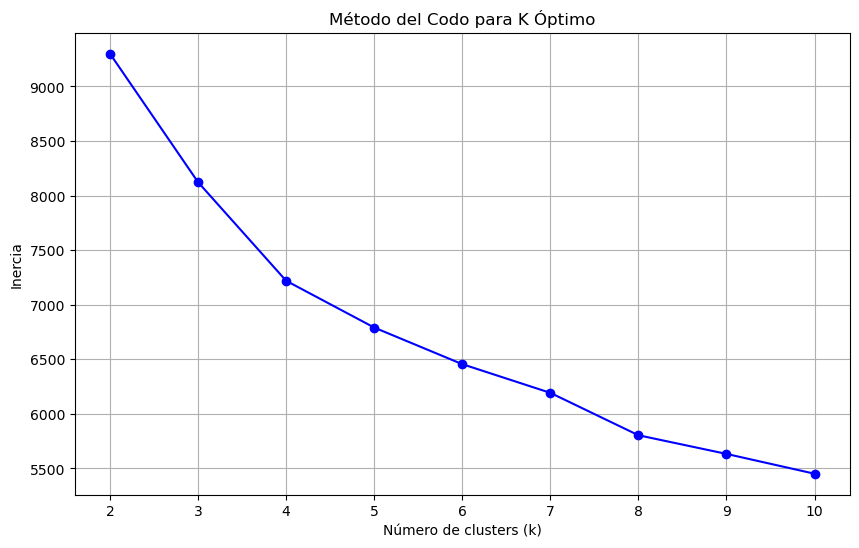

C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Para k=2, Silhouette Score: 0.5667
Para k=3, Silhouette Score: 0.1488
Para k=4, Silhouette Score: 0.1439
Para k=5, Silhouette Score: 0.1460
Para k=6, Silhouette Score: 0.1403
Para k=7, Silhouette Score: 0.1493


C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Para k=8, Silhouette Score: 0.1618
Para k=9, Silhouette Score: 0.1574
Para k=10, Silhouette Score: 0.1399

Análisis de clusters:
           freq_1    freq_2    freq_3    freq_4    freq_5    freq_6    freq_7  \
cluster                                                                         
0        0.154545  0.156364  0.141818  0.189091  0.301818  0.389091  0.267273   
1        0.555556  0.500000  0.555556  0.888889  1.333333  1.277778  1.277778   

         pedido_mediana  pedido_media  total_pizzas  unique_pizzas  \
cluster                                                              
0             14.956364     14.848879      2.341818       1.994545   
1             16.388889     14.682540     45.166667       7.000000   

         score_favorita  indice_fidelidad  
cluster                                    
0              1.307273         68.752236  
1             11.666667         25.681111  


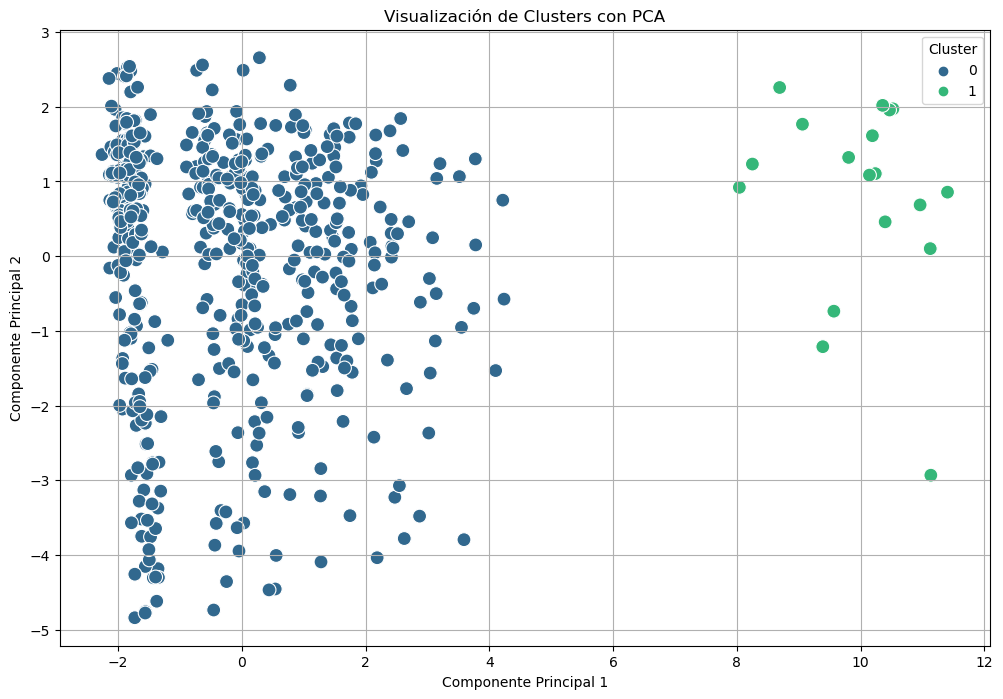


Perfiles de clusters:

--- Cluster 0 (550 clientes) ---
Día preferido: freq_6
Hora mediana: 15.0
Pizza favorita más común: 3
Índice de fidelidad promedio: 68.8%

--- Cluster 1 (18 clientes) ---
Día preferido: freq_5
Hora mediana: 16.4
Pizza favorita más común: 2
Índice de fidelidad promedio: 25.7%


In [133]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Eliminar duplicados (¡CRUCIAL!)
#df_final = df.drop_duplicates(subset='customer_id', keep='first')

# 2. Seleccionar features para el clustering
features = [
    'freq_1', 'freq_2', 'freq_3', 'freq_4', 'freq_5', 'freq_6', 'freq_7',
    'pedido_mediana', 'pedido_media',
    'total_pizzas', 'unique_pizzas', 'score_favorita', 'indice_fidelidad'
]

X = df_first2

# 3. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Método del Codo para encontrar k óptimo
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K Óptimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 5. Método de Silhouette para validar k
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para k={k}, Silhouette Score: {silhouette_avg:.4f}")

# 6. Entrenar modelo final con k óptimo (ejemplo con k=4)
k_optimo = 2  # Elige basado en el gráfico y silhouette score
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_first2['cluster'] = kmeans_final.fit_predict(X_scaled)

# 7. Analizar los clusters
cluster_analysis = df_first2.groupby('cluster')[features].mean()
print("\nAnálisis de clusters:")
print(cluster_analysis)

# 8. Visualizar clusters (usando PCA para reducción dimensional)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_first2['pca1'] = X_pca[:, 0]
df_first2['pca2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_first2, x='pca1', y='pca2', hue='cluster', palette='viridis', s=100)
plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 9. Perfiles de clusters
print("\nPerfiles de clusters:")
for cluster_id in range(k_optimo):
    cluster_data = df_first2[df_first2['cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} clientes) ---")
    print(f"Día preferido: {cluster_data[['freq_1', 'freq_2', 'freq_3', 'freq_4', 'freq_5', 'freq_6', 'freq_7']].mean().idxmax()}")
    print(f"Hora mediana: {cluster_data['pedido_mediana'].mean():.1f}")
    print(f"Pizza favorita más común: {cluster_data['pizza_favorita'].mode()[0]}")
    print(f"Índice de fidelidad promedio: {cluster_data['indice_fidelidad'].mean():.1f}%")

In [134]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# Filtrar clientes con más de 1 pedido (o el mínimo que quieras)
min_orders = 3  # Puedes ajustar este valor
df_filtered = df_first2[df_first2['num_orders'] >= min_orders]
X_filtered = X_scaled[df_first2['num_orders'] >= min_orders]

# Calcular matriz de distancias solo entre clientes filtrados
distancias = euclidean_distances(X_filtered)

# Poner infinitos en la diagonal para no comparar consigo mismo
np.fill_diagonal(distancias, np.inf)

# Encontrar la posición de la distancia mínima
min_index = np.argmin(distancias)
cliente_i, cliente_j = np.unravel_index(min_index, distancias.shape)

# Obtener los customer_id de los clientes más similares
id_cliente_i = df_filtered.iloc[cliente_i]['customer_id']
id_cliente_j = df_filtered.iloc[cliente_j]['customer_id']

print(f"Los clientes más similares (con al menos {min_orders} pedidos) son: {id_cliente_i} y {id_cliente_j}")
print(f"Distancia: {distancias[cliente_i, cliente_j]:.4f}")

# Opcional: Ver información de ambos clientes
print("\nInformación del cliente", id_cliente_i)
print(df_filtered[df_filtered['customer_id'] == id_cliente_i][['num_orders', 'pizza_favorita', 'indice_fidelidad']].to_string(index=False))

print("\nInformación del cliente", id_cliente_j)  
print(df_filtered[df_filtered['customer_id'] == id_cliente_j][['num_orders', 'pizza_favorita', 'indice_fidelidad']].to_string(index=False))

Los clientes más similares (con al menos 3 pedidos) son: 17.0 y 116.0
Distancia: 1.7428

Información del cliente 17.0
 num_orders  pizza_favorita  indice_fidelidad
          3               2              25.0

Información del cliente 116.0
 num_orders  pizza_favorita  indice_fidelidad
          3               2              50.0


In [135]:
new_df[new_df['customer_id']==17]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
34,1711,17,2,1,2025,24,5,20,40,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.5,19.25
35,1242,17,3,1,2025,14,3,18,3,5,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.5,19.25
36,1711,17,4,1,2025,24,5,20,40,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.5,19.25
37,2379,17,5,1,2025,7,6,19,41,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.5,19.25


In [136]:
new_df[new_df['customer_id']==116]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
173,1758,116,2,2,2025,5,4,19,25,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.0,19.333333
174,1522,116,4,1,2025,31,5,18,14,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.0,19.333333
175,2455,116,5,1,2024,27,12,21,13,5,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.0,19.333333


In [137]:
df_first.head()

,customer_id,hour,minute,diasemana,num_orders,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_favorita,score_favorita,indice_fidelidad,num_pizzas_diferentes
0,1,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.0,3,3,3,1,33.33,3
1,1,16,20,7,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.0,3,3,3,1,33.33,3
2,1,22,40,1,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,16.0,18.0,3,3,3,1,33.33,3
3,2,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,2,2,1,1,50.00,2
4,2,12,46,7,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,2,2,1,1,50.00,2


In [138]:
df_first3 = df_final.drop(['total_pizza','pizza_preferences','preferencias_detalladas','año','order_id','dia','mes','cantidad','pizza_id','total_pizzas','unique_pizzas','score_favorita'], axis=1)

In [139]:
df_first3 = df_first3.drop_duplicates(subset='customer_id', keep='first')

In [140]:
pizzas_ids = pd.read_sql("""
SELECT *
FROM pizza_names
""", conn)
pizzas_ids[pizzas_ids['pizza_id'] == 4]['pizza_name'].item()

'BBQ Chicken'

C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

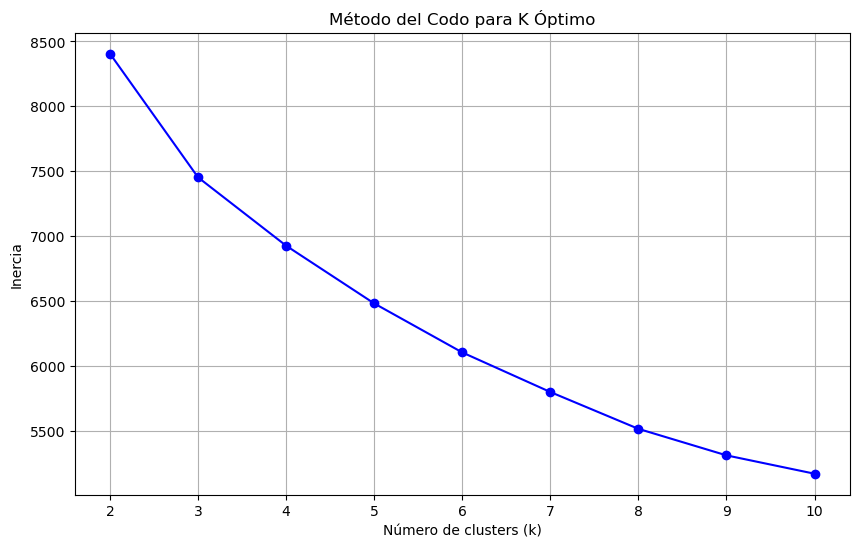

C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Para k=2, Silhouette Score: 0.1421
Para k=3, Silhouette Score: 0.1549
Para k=4, Silhouette Score: 0.1190
Para k=5, Silhouette Score: 0.1191
Para k=6, Silhouette Score: 0.1467


C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Para k=7, Silhouette Score: 0.1473
Para k=8, Silhouette Score: 0.1507
Para k=9, Silhouette Score: 0.1502
Para k=10, Silhouette Score: 0.1436

Análisis de clusters:
           freq_1    freq_2    freq_3    freq_4    freq_5    freq_6    freq_7  \
cluster                                                                         
0        0.122449  0.147959  0.081633  0.147959  0.198980  0.224490  0.107143   
1        0.171171  0.117117  0.162162  0.117117  0.342342  0.297297  0.270270   
2        0.173913  0.178261  0.165217  0.239130  0.321739  0.534783  0.395652   
3        0.387097  0.387097  0.516129  0.741935  1.258065  1.193548  0.903226   

         pedido_mediana  pedido_media  indice_fidelidad  
cluster                                                  
0             18.045918     18.045918         96.726378  
1              5.972973      6.445796         72.563243  
2             16.736957     16.257536         45.326652  
3             15.209677     14.175883         27.031290  


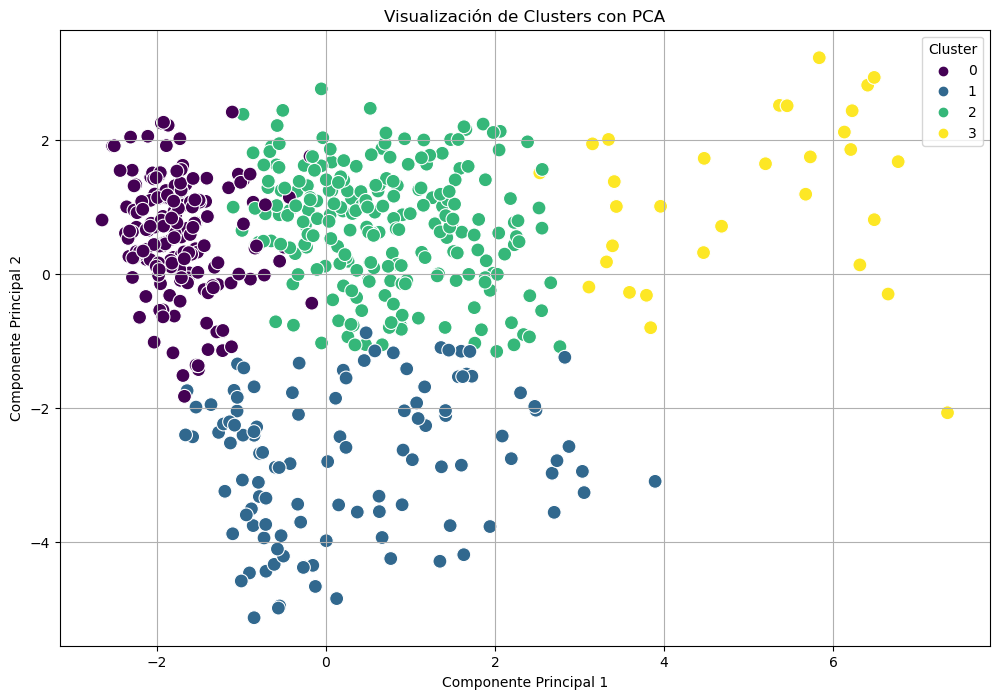


Perfiles de clusters:

--- Cluster 1 (196 clientes) ---
Día preferido: sábado
Hora mediana: 18.0
Hora media: 18.1
Pizza favorita más común:Meat Lovers
Índice de fidelidad promedio: 96.7%

--- Cluster 2 (111 clientes) ---
Día preferido: viernes
Hora mediana: 6.0
Hora media: 5.5
Pizza favorita más común:Meat Lovers
Índice de fidelidad promedio: 72.6%

--- Cluster 3 (230 clientes) ---
Día preferido: sábado
Hora mediana: 17.0
Hora media: 16.4
Pizza favorita más común:Margherita
Índice de fidelidad promedio: 45.3%

--- Cluster 4 (31 clientes) ---
Día preferido: viernes
Hora mediana: 17.0
Hora media: 14.8
Pizza favorita más común:Vegetarian
Índice de fidelidad promedio: 27.0%


<Figure size 640x480 with 0 Axes>

In [141]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Eliminar duplicados (¡CRUCIAL!)
#df_final = df.drop_duplicates(subset='customer_id', keep='first')

# 2. Seleccionar features para el clustering
features = [
    'freq_1', 'freq_2', 'freq_3', 'freq_4', 'freq_5', 'freq_6', 'freq_7',
    'pedido_mediana', 'pedido_media','indice_fidelidad'
]

X = df_first3

# 3. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Método del Codo para encontrar k óptimo
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K Óptimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# 5. Método de Silhouette para validar k
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para k={k}, Silhouette Score: {silhouette_avg:.4f}")

# 6. Entrenar modelo final con k óptimo (ejemplo con k=4)
k_optimo = 4  # Elige basado en el gráfico y silhouette score
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_first3['cluster'] = kmeans_final.fit_predict(X_scaled)

# 7. Analizar los clusters
cluster_analysis = df_first3.groupby('cluster')[features].mean()
print("\nAnálisis de clusters:")
print(cluster_analysis)

# 8. Visualizar clusters (usando PCA para reducción dimensional)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_first3['pca1'] = X_pca[:, 0]
df_first3['pca2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_first3, x='pca1', y='pca2', hue='cluster', palette='viridis', s=100)
plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
plt.savefig('cluster.png')
# 9. Perfiles de clusters
dias = ['lunes','martes','miercoles','jueves','viernes','sábado','domingo']
print("\nPerfiles de clusters:")
for cluster_id in range(k_optimo):
    cluster_data = df_first3[df_first3['cluster'] == cluster_id]
    value_to_show = cluster_data[['freq_1', 'freq_2', 'freq_3', 'freq_4', 'freq_5', 'freq_6', 'freq_7']].mean().idxmax()
    value_to_show = int(value_to_show[-1])
    print(f"\n--- Cluster {cluster_id+1} ({len(cluster_data)} clientes) ---")
    print(f"Día preferido: {dias[value_to_show-1]}")
    print(f"Hora mediana: {cluster_data['pedido_mediana'].median():.1f}")
    print(f"Hora media: {cluster_data['hour'].mean():.1f}")
    print(f"Pizza favorita más común:{pizzas_ids[pizzas_ids['pizza_id'] == cluster_data['pizza_favorita'].mode()[0]]['pizza_name'].item()}")
    print(f"Índice de fidelidad promedio: {cluster_data['indice_fidelidad'].mean():.1f}%")

In [142]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# Filtrar clientes con más de 1 pedido (o el mínimo que quieras)
min_orders = 4  # Puedes ajustar este valor
df_filtered = df_first3[df_first3['num_orders'] >= min_orders]
X_filtered = X_scaled[df_first3['num_orders'] >= min_orders]

# Calcular matriz de distancias solo entre clientes filtrados
distancias = euclidean_distances(X_filtered)

# Poner infinitos en la diagonal para no comparar consigo mismo
np.fill_diagonal(distancias, np.inf)

# Encontrar la posición de la distancia mínima
min_index = np.argmin(distancias)
cliente_i, cliente_j = np.unravel_index(min_index, distancias.shape)

# Obtener los customer_id de los clientes más similares
id_cliente_i = df_filtered.iloc[cliente_i]['customer_id']
id_cliente_j = df_filtered.iloc[cliente_j]['customer_id']

print(f"Los clientes más similares (con al menos {min_orders} pedidos) son: {id_cliente_i} y {id_cliente_j}")
print(f"Distancia: {distancias[cliente_i, cliente_j]:.4f}")

# Opcional: Ver información de ambos clientes
print("\nInformación del cliente", id_cliente_i)
print(df_filtered[df_filtered['customer_id'] == id_cliente_i][['num_orders', 'pizza_favorita', 'indice_fidelidad']].to_string(index=False))

print("\nInformación del cliente", id_cliente_j)  
print(df_filtered[df_filtered['customer_id'] == id_cliente_j][['num_orders', 'pizza_favorita', 'indice_fidelidad']].to_string(index=False))

Los clientes más similares (con al menos 4 pedidos) son: 681.0 y 733.0
Distancia: 1.4892

Información del cliente 681.0
 num_orders  pizza_favorita  indice_fidelidad
          4               1              37.5

Información del cliente 733.0
 num_orders  pizza_favorita  indice_fidelidad
          4               1              20.0


In [143]:
new_df[new_df['customer_id']==17]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
34,1711,17,2,1,2025,24,5,20,40,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.5,19.25
35,1242,17,3,1,2025,14,3,18,3,5,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.5,19.25
36,1711,17,4,1,2025,24,5,20,40,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.5,19.25
37,2379,17,5,1,2025,7,6,19,41,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.5,19.25


In [144]:
new_df[new_df['customer_id']==116]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
173,1758,116,2,2,2025,5,4,19,25,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2,19.0,19.333333
174,1522,116,4,1,2025,31,5,18,14,6,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.0,19.333333
175,2455,116,5,1,2024,27,12,21,13,5,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,1,19.0,19.333333


In [145]:
new_df[new_df['customer_id']==681]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
1022,1361,681,1,3,2025,27,1,22,38,1,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,3,6.0,12.0
1023,1908,681,2,2,2025,14,2,5,14,5,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,3,6.0,12.0
1024,1362,681,4,1,2024,13,11,22,8,3,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1,6.0,12.0
1025,2437,681,6,1,2025,15,1,6,51,3,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1,6.0,12.0
1026,1908,681,7,1,2025,14,2,5,14,5,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,3,6.0,12.0


In [146]:
new_df[new_df['customer_id']==733]

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,total_pizza,pedido_mediana,pedido_media
1121,2296,733,1,1,2025,21,5,19,49,3,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1,7.0,11.2
1122,1922,733,2,1,2024,25,11,6,29,1,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,2,7.0,11.2
1123,2144,733,4,1,2025,30,7,7,33,3,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1,7.0,11.2
1124,1223,733,5,1,2024,22,11,18,44,5,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,1,7.0,11.2
1125,1922,733,6,1,2024,25,11,6,29,1,...,1.0,0.0,2.0,0.0,1.0,0.0,0.0,2,7.0,11.2


In [147]:
pizzas_toppings = pd.read_sql("""
SELECT *
FROM pizza_toppings
""", conn)
print(pizzas_toppings)

    topping_id  topping_name
0            1  Tomato Sauce
1            2    Mozzarella
2            3      Mushroom
3            4         Onion
4            5   Bell Pepper
5            6        Olives
6            7     Pepperoni
7            8         Bacon
8            9          Beef
9           10       Chicken
10          11     Pineapple
11          12     BBQ Sauce
12          13      Jalapeno
13          14   Fresh Basil
14          15        Garlic


In [148]:
pizza_recipes = pd.read_sql("""
SELECT *
FROM pizza_recipes
""", conn)
print(pizza_recipes)

   pizza_id      toppings
0         1        1,2,14
1         2   1,2,3,4,5,6
2         3     1,2,7,8,9
3         4     1,2,10,12
4         5      1,2,11,6
5         6         1,2,7
6         7  1,3,4,5,6,15


In [149]:
df_final

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,pedido_mediana,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas,num_pizzas_diferentes
0,2460,1,3,1,2025,16,2,16,20,7,...,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
1,2460,1,4,1,2025,16,2,16,20,7,...,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
2,1990,1,6,1,2025,12,5,22,40,1,...,16.0,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3
3,2444,2,1,1,2025,15,6,12,46,7,...,12.0,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2
4,2444,2,3,1,2025,15,6,12,46,7,...,12.0,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2,...,18.0,18.000000,2,1,[6],6,2,100.00,"[{'pizza_id': 6, 'cantidad_total': 2}]",1
1219,1480,796,1,1,2025,9,8,19,45,6,...,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3
1220,2491,796,2,2,2025,7,1,9,43,2,...,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3
1221,1837,796,6,1,2024,27,11,16,23,3,...,16.0,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3


In [150]:
prueba = df_final.iloc[0]

In [151]:
prueba['pizza_preferences'][0]

3

In [152]:
pizza_recipes[pizza_recipes['pizza_id'] == prueba['pizza_preferences'][0]]['toppings'].item()

'1,2,7,8,9'

In [153]:
def parse_toppings(topping_str):
    return [int(x) for x in topping_str.split(",")]

def get_pizza_toppings(row):
    lista = []
    for pizza_id in row['pizza_preferences']:
        toppings_str = pizza_recipes.loc[pizza_recipes['pizza_id'] == pizza_id, 'toppings'].item()
        lista.extend(parse_toppings(toppings_str))
    unique_values = list(set(lista))
    return unique_values


In [154]:
df_final['toppings'] = df_final.apply(get_pizza_toppings, axis=1)

In [155]:
df_final.head()

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas,num_pizzas_diferentes,toppings
0,2460,1,3,1,2025,16,2,16,20,7,...,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
1,2460,1,4,1,2025,16,2,16,20,7,...,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
2,1990,1,6,1,2025,12,5,22,40,1,...,18.0,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
3,2444,2,1,1,2025,15,6,12,46,7,...,12.0,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9, 14]"
4,2444,2,3,1,2025,15,6,12,46,7,...,12.0,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9, 14]"


In [156]:
df_without = df_final.drop_duplicates(subset=['customer_id'])

In [157]:
df_without

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas,num_pizzas_diferentes,toppings
0,2460,1,3,1,2025,16,2,16,20,7,...,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
3,2444,2,1,1,2025,15,6,12,46,7,...,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9, 14]"
5,1197,3,3,1,2024,21,12,17,48,6,...,18.000000,2,2,"[3, 6]",3,1,50.00,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9]"
7,1294,4,1,1,2025,26,4,20,2,6,...,20.000000,1,1,[1],1,1,100.00,"[{'pizza_id': 1, 'cantidad_total': 1}]",1,"[1, 2, 14]"
8,1398,5,1,2,2025,16,7,19,56,3,...,14.857143,32,7,"[1, 2, 3, 4, 5, 6, 7]",3,7,21.88,"[{'pizza_id': 3, 'cantidad_total': 7}, {'pizza...",7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216,1612,791,2,1,2025,4,1,19,54,6,...,19.000000,1,1,[2],2,1,100.00,"[{'pizza_id': 2, 'cantidad_total': 1}]",1,"[1, 2, 3, 4, 5, 6]"
1217,1064,793,3,1,2025,11,1,23,52,6,...,23.000000,1,1,[3],3,1,100.00,"[{'pizza_id': 3, 'cantidad_total': 1}]",1,"[1, 2, 7, 8, 9]"
1218,1840,794,6,2,2025,4,2,18,50,2,...,18.000000,2,1,[6],6,2,100.00,"[{'pizza_id': 6, 'cantidad_total': 2}]",1,"[1, 2, 7]"
1219,1480,796,1,1,2025,9,8,19,45,6,...,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3,"[1, 2, 3, 4, 5, 6, 7, 14]"


In [158]:
exploded_df = df_without.explode('toppings')

dummies = pd.get_dummies(exploded_df['toppings'])

dummies_summed = dummies.groupby(level=0).sum()

df_dummies = pd.concat([df_without.drop('toppings', axis=1), dummies_summed], axis=1)

print(df_dummies)

      order_id  customer_id  pizza_id  cantidad   año  dia  mes  hour  minute  \
0         2460            1         3         1  2025   16    2    16      20   
3         2444            2         1         1  2025   15    6    12      46   
5         1197            3         3         1  2024   21   12    17      48   
7         1294            4         1         1  2025   26    4    20       2   
8         1398            5         1         2  2025   16    7    19      56   
...        ...          ...       ...       ...   ...  ...  ...   ...     ...   
1216      1612          791         2         1  2025    4    1    19      54   
1217      1064          793         3         1  2025   11    1    23      52   
1218      1840          794         6         2  2025    4    2    18      50   
1219      1480          796         1         1  2025    9    8    19      45   
1222      1286          798         2         1  2025   25    1    16      23   

      diasemana  ...  5  6 

In [159]:
df_dummies

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,5,6,7,8,9,10,11,12,14,15
0,2460,1,3,1,2025,16,2,16,20,7,...,0,0,1,1,1,1,0,1,0,0
3,2444,2,1,1,2025,15,6,12,46,7,...,0,0,1,1,1,0,0,0,1,0
5,1197,3,3,1,2024,21,12,17,48,6,...,0,0,1,1,1,0,0,0,0,0
7,1294,4,1,1,2025,26,4,20,2,6,...,0,0,0,0,0,0,0,0,1,0
8,1398,5,1,2,2025,16,7,19,56,3,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216,1612,791,2,1,2025,4,1,19,54,6,...,1,1,0,0,0,0,0,0,0,0
1217,1064,793,3,1,2025,11,1,23,52,6,...,0,0,1,1,1,0,0,0,0,0
1218,1840,794,6,2,2025,4,2,18,50,2,...,0,0,1,0,0,0,0,0,0,0
1219,1480,796,1,1,2025,9,8,19,45,6,...,1,1,1,0,0,0,0,0,1,0


In [160]:
df_dummies.columns

Index([               'order_id',             'customer_id',
                      'pizza_id',                'cantidad',
                           'año',                     'dia',
                           'mes',                    'hour',
                        'minute',               'diasemana',
                    'num_orders',                  'freq_1',
                        'freq_2',                  'freq_3',
                        'freq_4',                  'freq_5',
                        'freq_6',                  'freq_7',
                   'total_pizza',          'pedido_mediana',
                  'pedido_media',            'total_pizzas',
                 'unique_pizzas',       'pizza_preferences',
                'pizza_favorita',          'score_favorita',
              'indice_fidelidad', 'preferencias_detalladas',
        'num_pizzas_diferentes ',                         1,
                               2,                         3,
                        

In [161]:
df_dummies = df_dummies[['customer_id',1,2,3,4,5,6,7,8,9,10,11,12,14,15,'num_pizzas_diferentes ','indice_fidelidad','num_orders']]


In [162]:
df_dummies

,customer_id,1,2,3,4,5,6,7,8,9,10,11,12,14,15,num_pizzas_diferentes,indice_fidelidad,num_orders
0,1,1,1,0,0,0,0,1,1,1,1,0,1,0,0,3,33.33,2
3,2,1,1,0,0,0,0,1,1,1,0,0,0,1,0,2,50.00,1
5,3,1,1,0,0,0,0,1,1,1,0,0,0,0,0,2,50.00,2
7,4,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,100.00,1
8,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,7,21.88,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216,791,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,100.00,1
1217,793,1,1,0,0,0,0,1,1,1,0,0,0,0,0,1,100.00,1
1218,794,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,100.00,1
1219,796,1,1,1,1,1,1,1,0,0,0,0,0,1,0,3,50.00,3


In [163]:
df_dummies.columns = df_dummies.columns.astype(str)
df_dummies.head()

,customer_id,1,2,3,4,5,6,7,8,9,10,11,12,14,15,num_pizzas_diferentes,indice_fidelidad,num_orders
0,1,1,1,0,0,0,0,1,1,1,1,0,1,0,0,3,33.33,2
3,2,1,1,0,0,0,0,1,1,1,0,0,0,1,0,2,50.00,1
5,3,1,1,0,0,0,0,1,1,1,0,0,0,0,0,2,50.00,2
7,4,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,100.00,1
8,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,7,21.88,6


In [164]:
# Filtrar datos válidos
df_valido = df_dummies[df_dummies['num_orders'] >= 2].copy()

# Crear categorías de fidelidad REAL
def categorizar_fidelidad(fidelidad):
    if fidelidad >= 70: return 'SiemprePideLoMismo'
    elif fidelidad <= 40: return 'Experimentador'
    else: return 'Moderado'

df_valido['tipo_cliente'] = df_valido['indice_fidelidad'].apply(categorizar_fidelidad)

In [165]:
df_valido

,customer_id,1,2,3,4,5,6,7,8,9,10,11,12,14,15,num_pizzas_diferentes,indice_fidelidad,num_orders,tipo_cliente
0,1,1,1,0,0,0,0,1,1,1,1,0,1,0,0,3,33.33,2,Experimentador
5,3,1,1,0,0,0,0,1,1,1,0,0,0,0,0,2,50.00,2,Moderado
8,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,7,21.88,6,Experimentador
25,14,1,1,0,0,0,0,1,1,1,1,0,1,0,0,3,33.33,3,Experimentador
28,15,1,1,1,1,1,1,1,0,0,0,0,0,1,0,3,33.33,3,Experimentador
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1203,783,1,1,1,1,1,1,0,0,0,0,1,0,0,1,3,50.00,2,Moderado
1206,784,1,1,1,1,1,1,1,0,0,1,1,1,0,1,5,20.00,3,Experimentador
1211,785,1,1,0,0,0,1,1,1,1,0,1,0,0,0,2,50.00,2,Moderado
1213,790,1,1,1,1,1,1,1,1,1,0,0,0,1,0,3,33.33,3,Experimentador


In [167]:
conteo_tipos = df_valido['tipo_cliente'].value_counts()
print(conteo_tipos)

tipo_cliente
Experimentador        129
Moderado              122
SiemprePideLoMismo      5
Name: count, dtype: int64


In [213]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X = df_valido[['1','2','3','4','5','6','7','8','9','10','11','12','14','15','num_orders']]
y = df_valido['tipo_cliente']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [214]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {accuracy:.2%}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy del modelo: 78.85%

Reporte de clasificación:
                    precision    recall  f1-score   support

    Experimentador       0.83      0.77      0.80        26
          Moderado       0.75      0.84      0.79        25
SiemprePideLoMismo       0.00      0.00      0.00         1

          accuracy                           0.79        52
         macro avg       0.53      0.54      0.53        52
      weighted avg       0.78      0.79      0.78        52



C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\luisn\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [178]:
df_final

,order_id,customer_id,pizza_id,cantidad,año,dia,mes,hour,minute,diasemana,...,pedido_media,total_pizzas,unique_pizzas,pizza_preferences,pizza_favorita,score_favorita,indice_fidelidad,preferencias_detalladas,num_pizzas_diferentes,toppings
0,2460,1,3,1,2025,16,2,16,20,7,...,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
1,2460,1,4,1,2025,16,2,16,20,7,...,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
2,1990,1,6,1,2025,12,5,22,40,1,...,18.000000,3,3,"[3, 4, 6]",3,1,33.33,"[{'pizza_id': 3, 'cantidad_total': 1}, {'pizza...",3,"[1, 2, 7, 8, 9, 10, 12]"
3,2444,2,1,1,2025,15,6,12,46,7,...,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9, 14]"
4,2444,2,3,1,2025,15,6,12,46,7,...,12.000000,2,2,"[1, 3]",1,1,50.00,"[{'pizza_id': 1, 'cantidad_total': 1}, {'pizza...",2,"[1, 2, 7, 8, 9, 14]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218,1840,794,6,2,2025,4,2,18,50,2,...,18.000000,2,1,[6],6,2,100.00,"[{'pizza_id': 6, 'cantidad_total': 2}]",1,"[1, 2, 7]"
1219,1480,796,1,1,2025,9,8,19,45,6,...,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3,"[1, 2, 3, 4, 5, 6, 7, 14]"
1220,2491,796,2,2,2025,7,1,9,43,2,...,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3,"[1, 2, 3, 4, 5, 6, 7, 14]"
1221,1837,796,6,1,2024,27,11,16,23,3,...,14.666667,4,3,"[1, 2, 6]",2,2,50.00,"[{'pizza_id': 2, 'cantidad_total': 2}, {'pizza...",3,"[1, 2, 3, 4, 5, 6, 7, 14]"


In [179]:
df_favorita = df_final[['pizza_favorita','total_pizzas', 'unique_pizzas', 'indice_fidelidad','hour','total_pizzas']]

In [180]:
df_favorita

,pizza_favorita,total_pizzas,unique_pizzas,indice_fidelidad,hour,total_pizzas
0,3,3,3,33.33,16,3
1,3,3,3,33.33,16,3
2,3,3,3,33.33,22,3
3,1,2,2,50.00,12,2
4,1,2,2,50.00,12,2
...,...,...,...,...,...,...
1218,6,2,1,100.00,18,2
1219,2,4,3,50.00,19,4
1220,2,4,3,50.00,9,4
1221,2,4,3,50.00,16,4


In [181]:
from sklearn import svm
from sklearn.model_selection import train_test_split
X_piza = df_favorita[['total_pizzas','unique_pizzas','indice_fidelidad','hour']]
y_piza = df_favorita['pizza_favorita']

In [182]:
print(f"X_piza shape: {X_piza.shape}")  # Debe ser (256, 3)
print(f"y_piza shape: {y_piza.shape}")  # Debe ser (256,)

X_piza shape: (1223, 5)
y_piza shape: (1223,)


In [183]:
X_train_piza, X_test_piza, y_train_piza, y_test_piza = train_test_split(X_piza, y_piza, test_size=0.2, random_state=42,stratify=y_piza)

In [184]:
clf = svm.SVC()
clf.fit(X_train_piza, y_train_piza)
y_pred = clf.predict(X_test_piza)

In [185]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test_piza, y_pred)
print(f"Accuracy: {accuracy:.2%}")

print("\nReporte de clasificación:")
print(classification_report(y_test_piza, y_pred))

Accuracy: 33.47%

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.20      0.04      0.07        49
           2       0.36      0.44      0.40        61
           3       0.31      0.75      0.44        64
           4       0.00      0.00      0.00        20
           5       0.00      0.00      0.00        14
           6       0.71      0.17      0.27        30
           7       0.00      0.00      0.00         7

    accuracy                           0.33       245
   macro avg       0.23      0.20      0.17       245
weighted avg       0.30      0.33      0.26       245



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [186]:
# Luego en Python
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Cargar datos
df_runner = pd.read_sql("""
SELECT 
    ro.order_id, 
    ro.runner_id,ro.pickup_time, ro.distance, ro.duration,ro.cancellation,
    COUNT(co.pizza_id) as total_pizzas
FROM runner_orders ro
JOIN customer_orders co 
    ON ro.order_id = co.order_id
WHERE ro.duration IS NOT NULL
GROUP BY ro.order_id, ro.runner_id
ORDER BY total_pizzas DESC
""", conn)

# Preprocesar: convertir distance y duration a números
df_runner

,order_id,runner_id,pickup_time,distance,duration,cancellation,total_pizzas
0,1106,10,2024-12-13 17:05:58,3.2,19 minutes,None,4
1,1204,14,2025-06-01 18:00:39,2.1 km,16 minutes,None,4
2,1331,1,2025-07-13 16:26:20,4.4km,15 minutes,None,4
3,1401,12,2025-04-10 16:44:09,3.3km,8 minutes,None,4
4,1752,4,2025-03-02 17:53:35,4.2km,17 minutes,None,4
...,...,...,...,...,...,...,...
1405,2492,2,2025-05-30 18:08:19,0.8km,7 minutes,None,1
1406,2493,10,2025-04-11 20:04:50,3.7km,14 minutes,None,1
1407,2494,3,2025-01-04 23:15:08,7.2km,29 minutes,None,1
1408,2495,10,2025-08-05 19:37:25,5.7km,18 minutes,None,1


In [187]:
df_runner.isnull().sum()

order_id           0
runner_id          0
pickup_time       18
distance          24
duration           0
cancellation    1395
total_pizzas       0
dtype: int64

In [188]:
df_runner.isnull().sum()

order_id           0
runner_id          0
pickup_time       18
distance          24
duration           0
cancellation    1395
total_pizzas       0
dtype: int64

In [189]:
df_runner['pickup_time'] = pd.to_datetime(df_runner['pickup_time'])
df_runner['año'] = df_runner['pickup_time'].dt.year 
df_runner['dia'] = df_runner['pickup_time'].dt.day
df_runner['mes'] = df_runner['pickup_time'].dt.month
df_runner['hour'] = df_runner['pickup_time'].dt.hour
df_runner['minute'] = df_runner['pickup_time'].dt.minute
df_runner['diasemana'] = df_runner['pickup_time'].dt.dayofweek+1
df_runner['duration_numeric'] = df_runner['duration'].str.extract(r'(\d+)').astype(int)
df_runner['distance_numeric'] = (
    df_runner['distance']
    .str.extract(r'(\d+(?:\.\d+)?)')  # números con posible parte decimal
    .astype(float)
)

In [190]:
df_onlycancellation = df_runner[df_runner['cancellation'].notnull()]

In [191]:
df_onlycancellation

,order_id,runner_id,pickup_time,distance,duration,cancellation,total_pizzas,año,dia,mes,hour,minute,diasemana,duration_numeric,distance_numeric
20,1226,10,2025-06-29 16:53:13,None,22 minutes,custmer_no_sho,3,2025.0,29.0,6.0,16.0,53.0,7.0,22,NaN
57,1725,9,NaT,None,11 minutes,address issue,3,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN
72,1948,5,NaT,None,24 minutes,address issue,3,NaN,NaN,NaN,NaN,NaN,NaN,24,NaN
201,1452,14,2025-02-13 18:04:54,None,18 minutes,runner sick,2,2025.0,13.0,2.0,18.0,4.0,4.0,18,NaN
300,1882,14,NaT,None,26 minutes,restaurant_cancelled,2,NaN,NaN,NaN,NaN,NaN,NaN,26,NaN
392,2240,7,NaT,None,22 minutes,custmer_no_sho,2,NaN,NaN,NaN,NaN,NaN,NaN,22,NaN
635,1253,5,NaT,None,5 minutes,runner sick,1,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN
653,1277,13,2025-05-13 00:26:13,None,9 minutes,runner sick,1,2025.0,13.0,5.0,0.0,26.0,2.0,9,NaN
779,1481,8,NaT,None,25 minutes,customer no show,1,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
871,1639,10,NaT,None,33 minutes,customer no show,1,NaN,NaN,NaN,NaN,NaN,NaN,33,NaN


In [192]:
df_runner = df_runner.drop('cancellation', axis=1)

In [193]:
df_runner.dropna(axis=0)

,order_id,runner_id,pickup_time,distance,duration,total_pizzas,año,dia,mes,hour,minute,diasemana,duration_numeric,distance_numeric
0,1106,10,2024-12-13 17:05:58,3.2,19 minutes,4,2024.0,13.0,12.0,17.0,5.0,5.0,19,3.2
1,1204,14,2025-06-01 18:00:39,2.1 km,16 minutes,4,2025.0,1.0,6.0,18.0,0.0,7.0,16,2.1
2,1331,1,2025-07-13 16:26:20,4.4km,15 minutes,4,2025.0,13.0,7.0,16.0,26.0,7.0,15,4.4
3,1401,12,2025-04-10 16:44:09,3.3km,8 minutes,4,2025.0,10.0,4.0,16.0,44.0,4.0,8,3.3
4,1752,4,2025-03-02 17:53:35,4.2km,17 minutes,4,2025.0,2.0,3.0,17.0,53.0,7.0,17,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405,2492,2,2025-05-30 18:08:19,0.8km,7 minutes,1,2025.0,30.0,5.0,18.0,8.0,5.0,7,0.8
1406,2493,10,2025-04-11 20:04:50,3.7km,14 minutes,1,2025.0,11.0,4.0,20.0,4.0,5.0,14,3.7
1407,2494,3,2025-01-04 23:15:08,7.2km,29 minutes,1,2025.0,4.0,1.0,23.0,15.0,6.0,29,7.2
1408,2495,10,2025-08-05 19:37:25,5.7km,18 minutes,1,2025.0,5.0,8.0,19.0,37.0,2.0,18,5.7


In [194]:
df_runner.isnull().sum()

order_id             0
runner_id            0
pickup_time         18
distance            24
duration             0
total_pizzas         0
año                 18
dia                 18
mes                 18
hour                18
minute              18
diasemana           18
duration_numeric     0
distance_numeric    24
dtype: int64

In [195]:
df_runner = df_runner.fillna(df_runner['distance_numeric'].mean())
df_runner = df_runner.fillna(df_runner['año'].mode()[0])
df_runner = df_runner.fillna(df_runner['dia'].mode()[0])
df_runner = df_runner.fillna(df_runner['mes'].mode()[0])
df_runner = df_runner.fillna(df_runner['hour'].mode()[0])
df_runner = df_runner.fillna(df_runner['minute'].mode()[0])
# Crear variables derivadas
df_runner['fin_semana'] = df_runner['diasemana'].apply(lambda x: 1 if x in [6,0] else 0)
df_runner['pizzas_per_km'] = df_runner['total_pizzas'] / df_runner['distance_numeric']

In [211]:
from sklearn.model_selection import train_test_split
X_runner = df_runner[['distance_numeric','total_pizzas','pizzas_per_km','runner_id']]
y_runner = df_runner[['duration_numeric']]

In [201]:
X_train_runner, X_test_runner, y_train_runner, y_test_runner = train_test_split(X_runner, y_runner, test_size=0.2, random_state=42)

In [202]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [203]:
scaler = StandardScaler()
X_train_runner_scaled = scaler.fit_transform(X_train_runner)

In [204]:
model.fit(X_train_runner_scaled, y_train_runner)

LinearRegression()

In [205]:
X_test_runner_scaled = scaler.transform(X_test_runner)

In [206]:
y_pred_runner = model.predict(X_test_runner_scaled)

In [207]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test_runner, y_pred_runner)
mae = mean_absolute_error(y_test_runner, y_pred_runner)
r2 = r2_score(y_test_runner, y_pred_runner)

print(f"MSE: {mse:.2f}") 
print(f"MAE: {mae:.2f}")   
print(f"R²: {r2:.2f}") 

MSE: 24.77
MAE: 3.71
R²: 0.54


In [210]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Definir modelos
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
}
for name, model in models.items():
    scores = cross_val_score(model, X_train_runner, y_train_runner, cv=5)
    print(f"{name}: {scores.mean():.4f} (±{scores.std():.4f})")

Linear Regression: 0.5914 (±0.0335)
Ridge: 0.5914 (±0.0334)
Lasso: 0.5865 (±0.0281)
ElasticNet: 0.5694 (±0.0267)
